<center>
    <img src="https://uhapo.co.in/wp-content/uploads/2024/05/Breast-Cancer-Screening-Early-Detection-BLOG.png" width="700" height="400">
</center>

<center>
    <font size="6">Breast Cancer Prediction Model</font>
</center>

# **Project Objective:**
## Automating Breast Cancer Diagnosis using kNN

#### **1. Domain Context :-**
Breast cancer is a major global health concern for women. Early detection is the most critical factor in improving survival rates. Traditionally, doctors extract cell tissues through a Fine Needle Aspirate (FNA) procedure and manually analyze the digitized images under a microscope. This diagnostic method can be highly complex and time-consuming.

#### **2. Problem Definition :-**
Manual classification of tumor cells is subject to human error and can delay critical test results. There is a significant need for an automated, data-driven system that can analyze historical patient data and the specific properties of tumor cells (such as radius, texture, and perimeter) to quickly and accurately identify new cases.

#### **3. Project Goals & Methodology :-**
The objective of this project is to develop a predictive machine learning model utilizing the k-Nearest Neighbors (kNN) algorithm to automate the diagnostic process.

- **Data:** We will use the Breast Cancer Wisconsin (Diagnostic) Data Set, which contains features extracted from digitized images of FNA tests.

- **Goal:** To train the model to classify with high accuracy whether a breast mass is Malignant (cancerous) or Benign (non-cancerous) based on these numerical features.

- **Impact:** This automated model will provide medical professionals with a fast, reliable screening tool and a valuable "second opinion," ultimately aiding in prompt decision-making and early treatment.

## Importing necessary libraries..

In [ ]:
# libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# libraries to help with data visualization
import seaborn as sns
import matplotlib.pyplot as plt

# library to split data
from sklearn.model_selection import train_test_split

# library to build model for prediction
from sklearn.neighbors import KNeighborsClassifier

# library to get different metric score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# library to scalled data
from sklearn.preprocessing import StandardScaler

## Loading the dataset..

In [ ]:
# Mounting Google Drive to access the dataset
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
data = pd.read_csv("/content/drive/MyDrive/Datasets/Breast Cancer Dataset.csv")


## Data Overview..

- View the first and last 5 rows of the dataset:-

In [ ]:
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
data.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


- The dataset contains information about different patient..

## Understand the shape of the dataset..

In [ ]:
data.shape

(569, 33)

- The dataset has 569 rows and 33 columns.

## Check the data types of the columns for the dataset..

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

- There are total 33 columns and 569 rows in the dataset.
- We have only one categorical variables - Diagnosis.
- All other variables are continuous.
- The main features contain no missing values, except for an entirely empty 'Unnamed: 32' column that needs to be dropped.

## Checking for duplicate values..

In [ ]:
data.duplicated().sum()

np.int64(0)

- There are no duplicate values in the dataset.

## Checking for missing values..

In [ ]:
data.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


- The main features contain no missing values, except for an entirely empty 'Unnamed: 32' column that needs to be dropped.

## Statistical Summary..

In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


#### **Observation :-**
- **The Empty Column (Unnamed: 32):** The summary shows a count of 0.0 for Unnamed: 32 with all other values as NaN. This proves the column is completely empty and must be dropped.
- **The Threat of the id Column:** The id column contains massive numerical values (up to $9.11 \times 10^8$) which have no medical relevance. Because kNN calculates physical distance between data points, keeping this column will severely distort the model's predictions. It must be dropped.
- **The Need for Feature Scaling (Critical for kNN):** There is a drastic difference in the scale of various features. For example, area_mean ranges from 143.5 to 2501.0, whereas smoothness_mean ranges only from 0.052 to 0.163. Without Feature Scaling (Standardization), the kNN algorithm will unfairly prioritize features with larger numbers.
- **Presence of Potential Outliers:** By comparing the 75% (3rd Quartile) and the max values, we can identify extreme data points. For instance, 75% of the area_mean data falls below 782.7, but the maximum value suddenly jumps to 2501.0. This indicates the presence of abnormally large tumors (outliers) that need to be investigated visually.

In [ ]:
# Printing number of count of each unique value in diagnosis variable
data["diagnosis"].value_counts()

,count
diagnosis,
B,357
M,212


In [ ]:
data["diagnosis"] = data.diagnosis.astype("category")

In [ ]:
data.groupby(["diagnosis"]).count()

/tmp/ipykernel_13851/2828053007.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(["diagnosis"]).count()


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
diagnosis,,,,,,,,,,,,,,,,,,,,,
B,357,357,357,357,357,357,357,357,357,357,...,357,357,357,357,357,357,357,357,357,0
M,212,212,212,212,212,212,212,212,212,212,...,212,212,212,212,212,212,212,212,212,0


- Class distribution among B and M is almost 2:1. The model better predict B and M.

## Dropped unnecessary columns..

In [ ]:
# Dropping the "id" and "unnamed: 32" columns
clean_data = data.drop(["id","Unnamed: 32"], axis = 1)

In [ ]:
clean_data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
clean_data.shape

(569, 31)

- The dataset has 569 rows and 31 columns.

## <a name='link2'>Exploratory Data Analysis (EDA) Summary</a>

### **Note:** The EDA section has been covered multiple times in the previous case studies. In this case study, we will mainly focus on the model building aspects. We will only be looking at the key observations from EDA.

### Univariate analysis..

In [ ]:
def histogram_boxplot(data, feature, figsize=(15,10), kde = False, bins=None):
  """
  Boxplot and histplot combined

  data: dataframe
  feature: dataframe column
  figsize: size of figure (default (15,10))
  kde: whether to show the density curve (default False)
  bins: number of bins for histgrom (default None)
  """
  f2, (ax_box2, ax_hist2) = plt.subplots(
      nrows = 2, # Number of rows of the subplot grid = 2
      sharex = True, # x-axis will be shared among all subplots
      gridspec_kw = {"height_ratios": (0.25, 0.75)},
      figsize = figsize,
  ) # Creating the 2 subplots
  sns.boxplot(
      data = data, x=feature, ax=ax_box2, showmeans=True, color = "teal"
  ) # Boxplot will be created and a tringle will indicate the mean value of the column
  sns.histplot(
      data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
  ) if bins else sns.histplot(
      data=data, x=feature, kde=kde, ax=ax_hist2
  ) # For histgrom
  ax_hist2.axvline(
      data[feature].mean(), color="green", linestyle="--"
  ) # Add mean to the histogram
  ax_hist2.axvline(
      data[feature].median(),color="black", linestyle="-"
  ) # Add median to the histgrom

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        hue=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

#### Observation on diagnosis :-


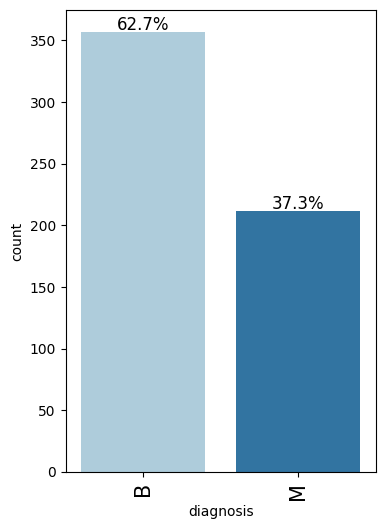

In [ ]:
labeled_barplot(clean_data, "diagnosis", perc=True)

- The bar plot illustrates the class distribution of the target variable, 'diagnosis'. It shows a moderate class imbalance where the majority of the instances are Benign ('B') accounting for 62.7% of the dataset, while Malignant ('M') cases make up the minority class at 37.3%.

#### Observation on radius_mean :-

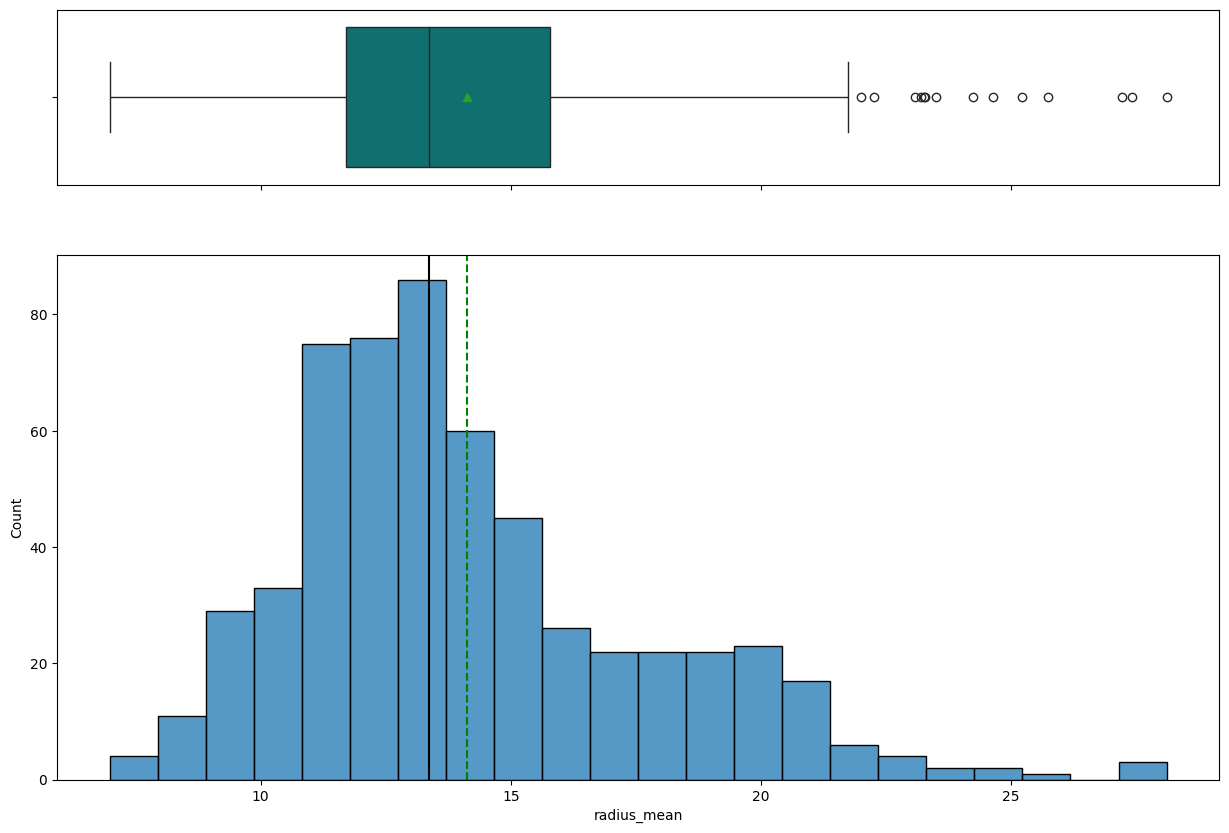

In [ ]:
histogram_boxplot(clean_data, "radius_mean")

- The combined histogram and boxplot for radius_mean reveal a right-skewed (positively skewed) distribution. The majority of the data is concentrated between the values of 10 and 15. The solid line representing the median is positioned to the left of the dashed line (the mean), which is characteristic of positive skewness. Furthermore, the boxplot clearly identifies multiple outliers on the higher end of the scale (values approximately above 21).

#### Observation on texture_mean :-

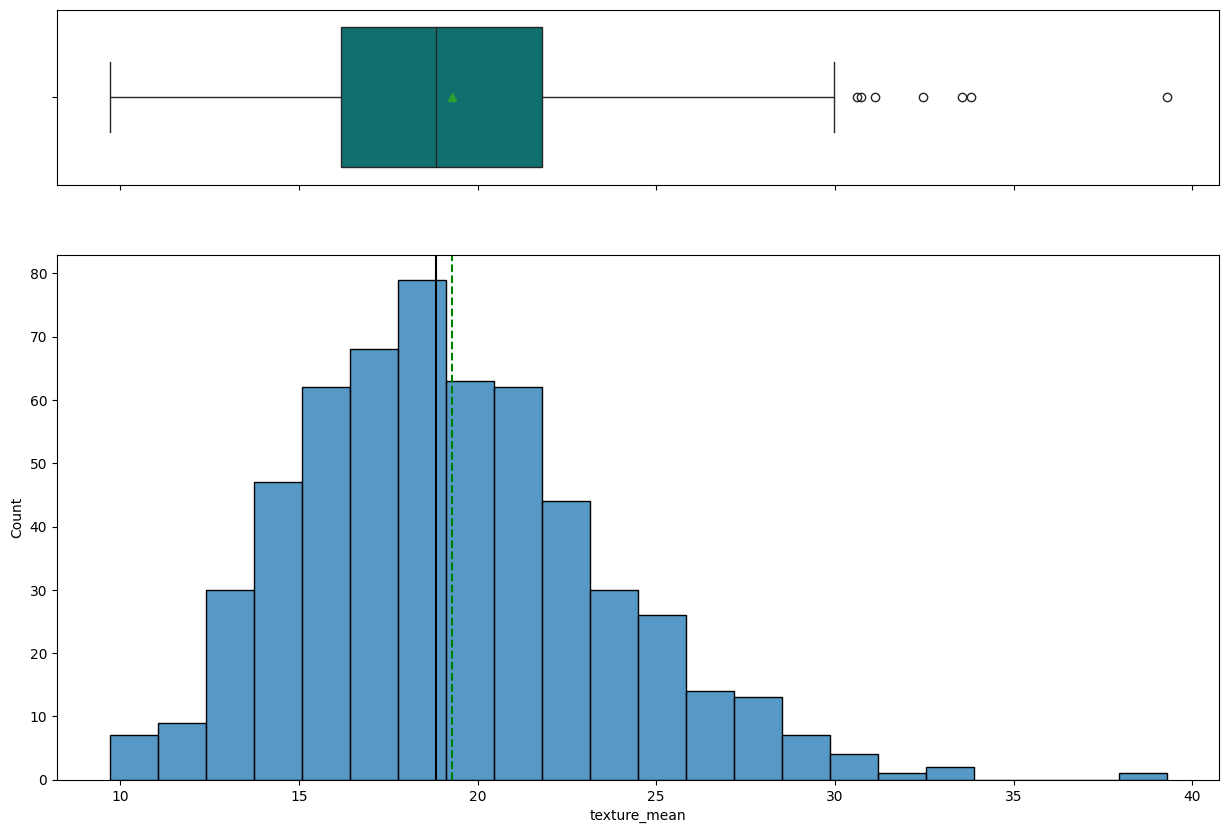

In [ ]:
histogram_boxplot(clean_data, "texture_mean")

- The combined histogram and boxplot for texture_mean display a distribution that is approximately normal, though with a very slight right skew. The bulk of the data values are concentrated between 15 and 22. The mean (green dashed line) is almost aligned with the median (solid line), further indicating near-normality. However, the boxplot highlights a few distinct outliers on the higher end (values roughly above 30).

#### Observation on perimeter_mean :-

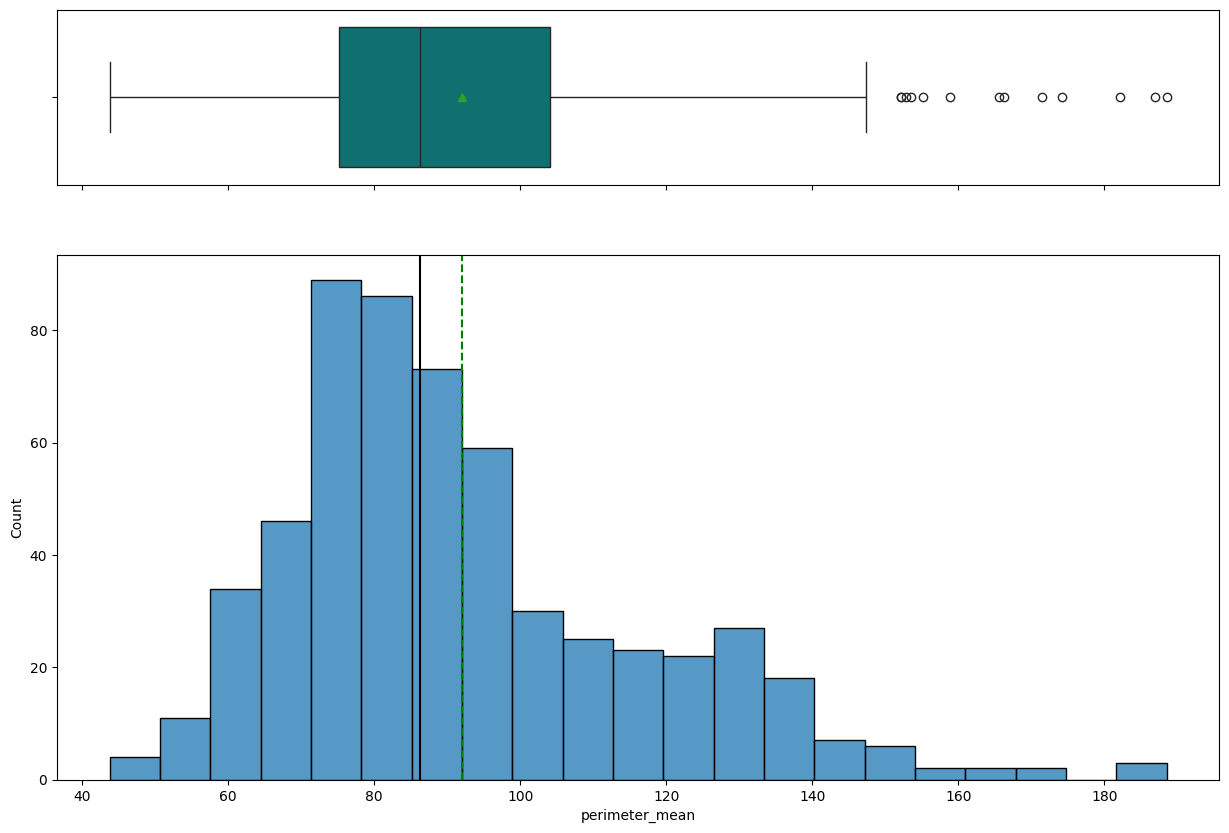

In [ ]:
histogram_boxplot(clean_data, "perimeter_mean")

- The combined histogram and boxplot for perimeter_mean exhibit a distinctly right-skewed (positively skewed) distribution, visually identical to the radius_mean feature. The data is predominantly clustered between 70 and 90. The mean (dashed line) is pulled noticeably to the right of the median (solid line). Furthermore, the boxplot reveals a significant cluster of outliers on the higher end, representing extreme values beyond 140.

#### Observation on area_mean :-

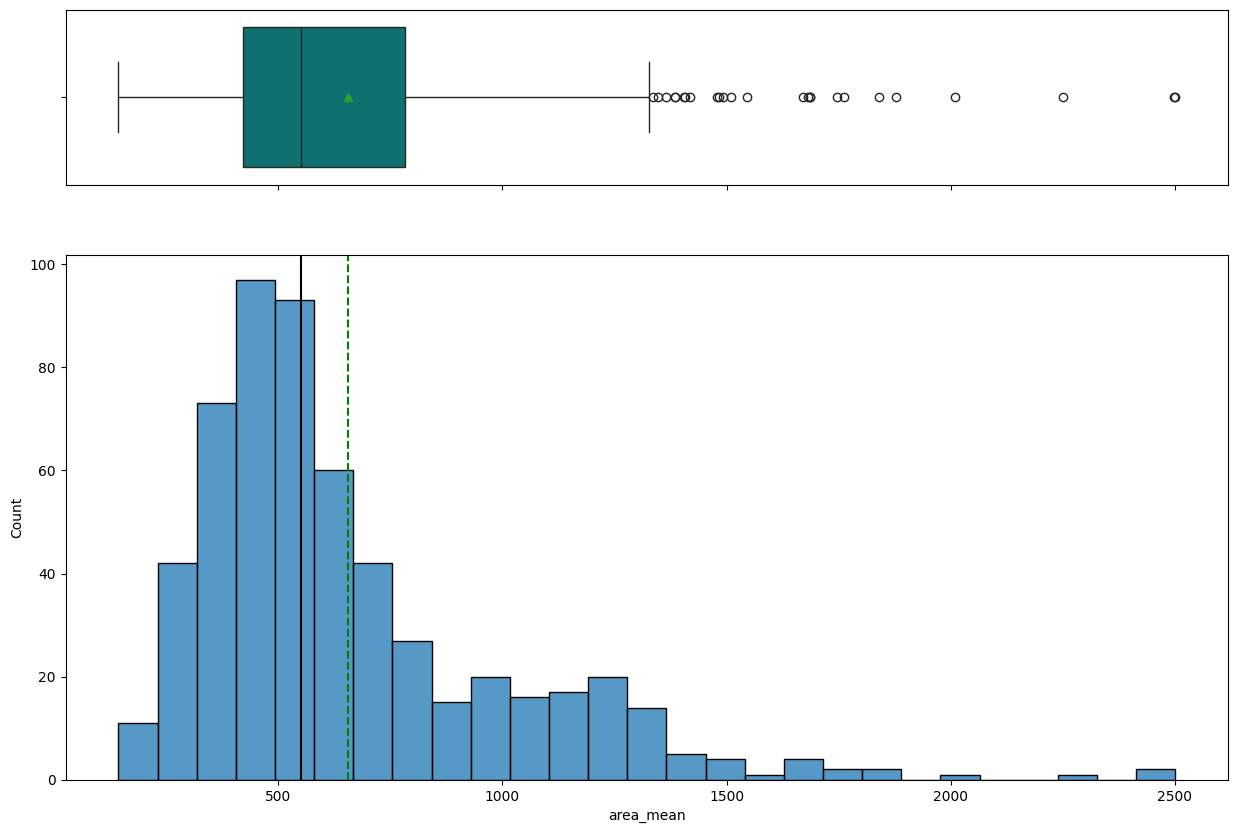

In [ ]:
histogram_boxplot(clean_data, "area_mean")

- The combined histogram and boxplot for area_mean display a highly right-skewed (positively skewed) distribution. The majority of the area values fall between 400 and 700. The mean (dashed line) is significantly pulled to the right of the median (solid line) due to the extreme long tail. The boxplot exposes a massive spread of extreme outliers starting from roughly 1100 and extending all the way up to 2500.

#### Observation on smoothness_mean :-

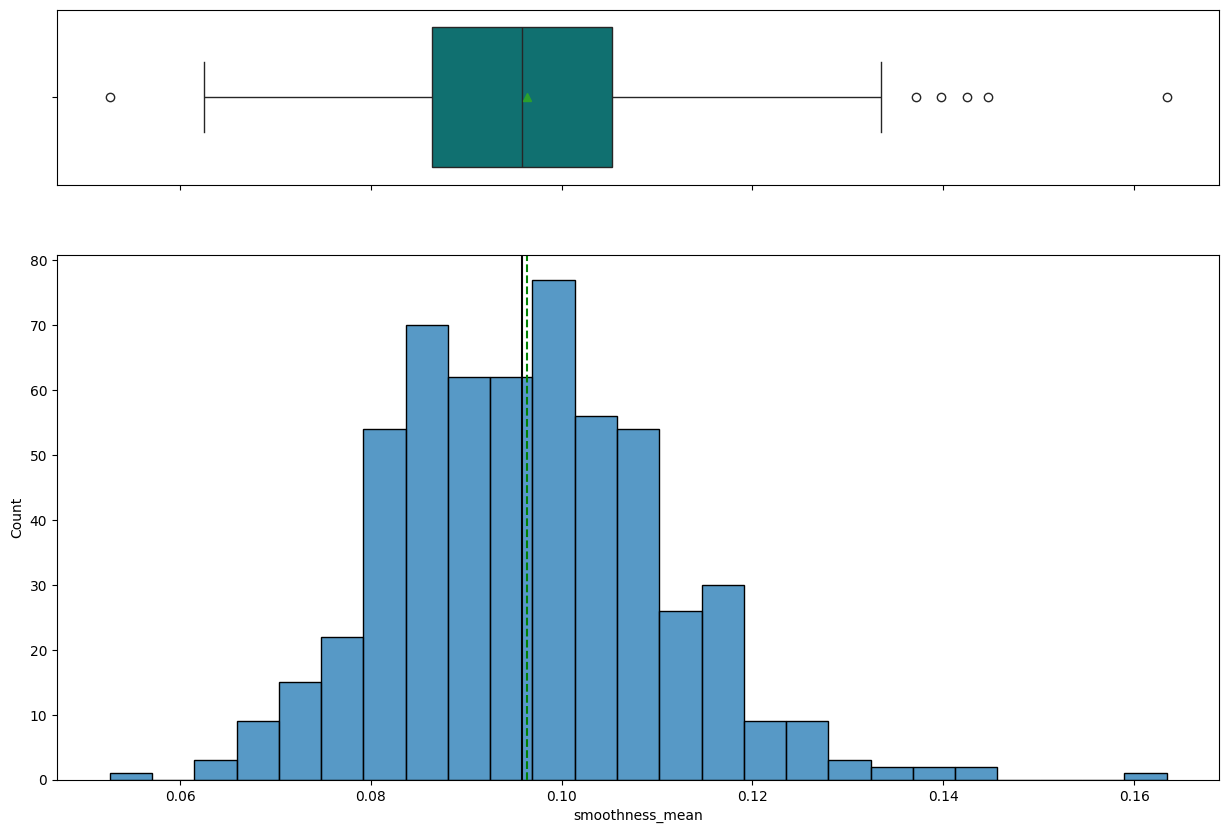

In [ ]:
histogram_boxplot(clean_data, "smoothness_mean")

- The combined histogram and boxplot for smoothness_mean exhibit a nearly normal (symmetrical) distribution. The mean (dashed line) and median (solid line) are closely aligned, confirming the symmetry. A critical observation is the scale of the x-axis: the values are extremely small decimals, primarily concentrated between 0.08 and 0.11. The boxplot reveals a few mild outliers on both the lower and higher ends of the distribution.

#### Observation on compactness_mean :-

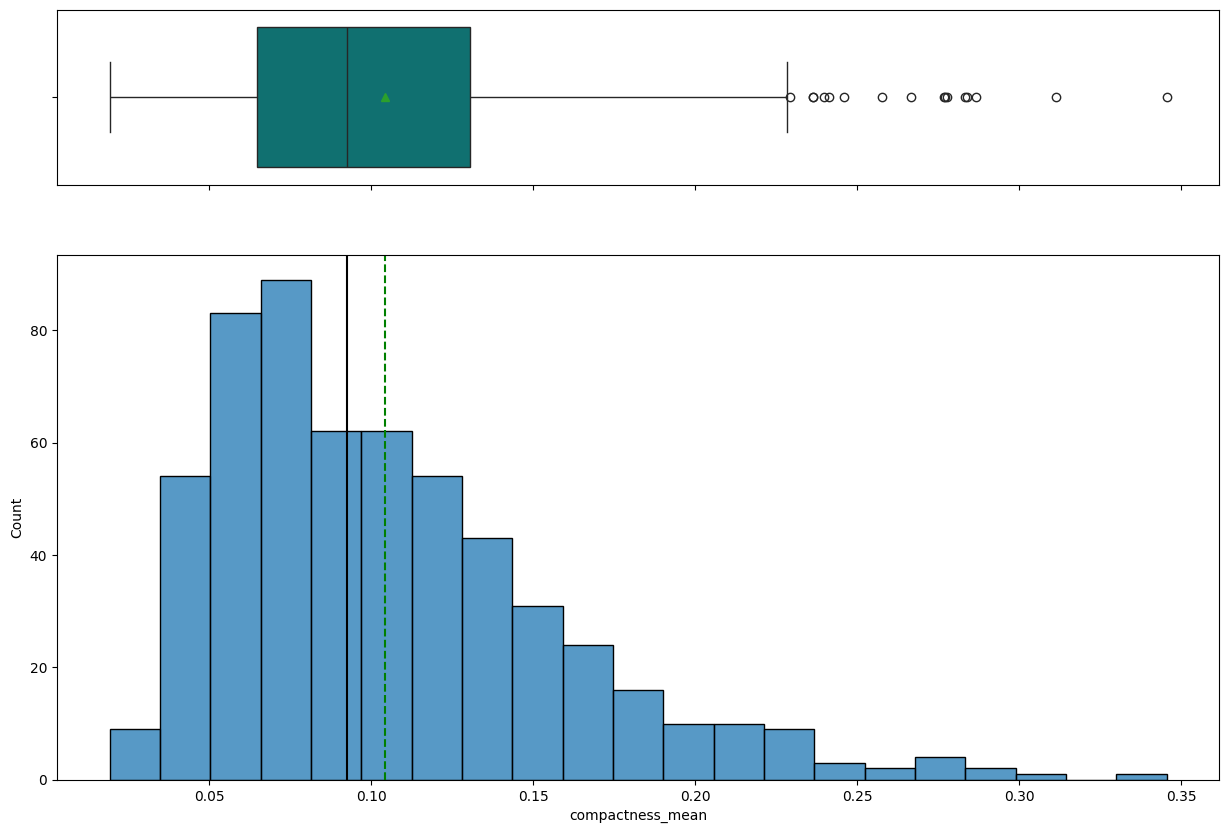

In [ ]:
histogram_boxplot(clean_data, "compactness_mean")

- The combined histogram and boxplot for compactness_mean reveal a moderately right-skewed (positively skewed) distribution. The majority of the data points are clustered between 0.05 and 0.15. As expected with right-skewed data, the mean (dashed line) is pulled to the right of the median (solid line). The boxplot clearly identifies multiple outliers on the higher end, with values extending up to approximately 0.35.

#### Observation on concavity_mean :-

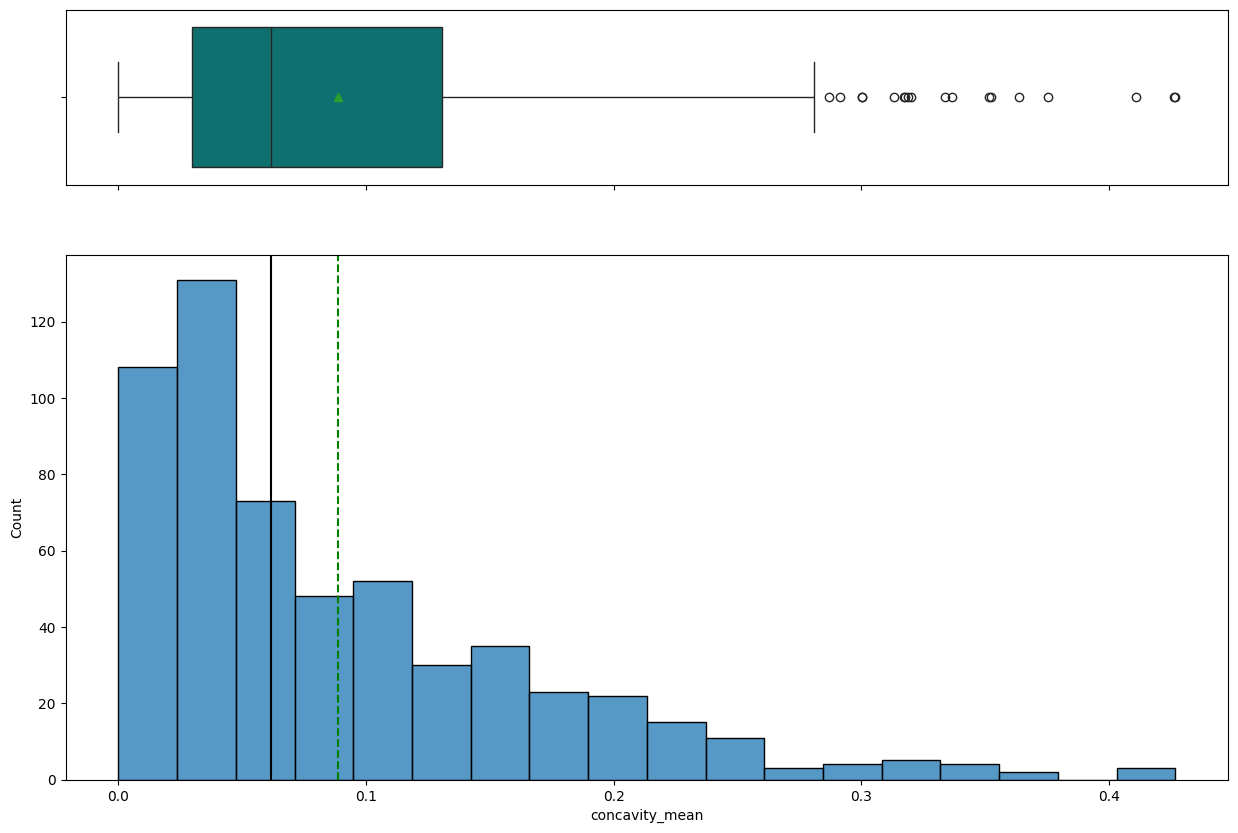

In [ ]:
histogram_boxplot(clean_data, "concavity_mean")

- The combined histogram and boxplot for concavity_mean exhibit a highly right-skewed (positively skewed) distribution. The data is heavily concentrated at the lower end, predominantly between 0.00 and 0.05. Consequently, the mean (dashed line) is pulled significantly to the right of the median (solid line). The boxplot highlights a long tail with multiple extreme outliers reaching up to 0.4.

#### Observation on concave points_mean :-

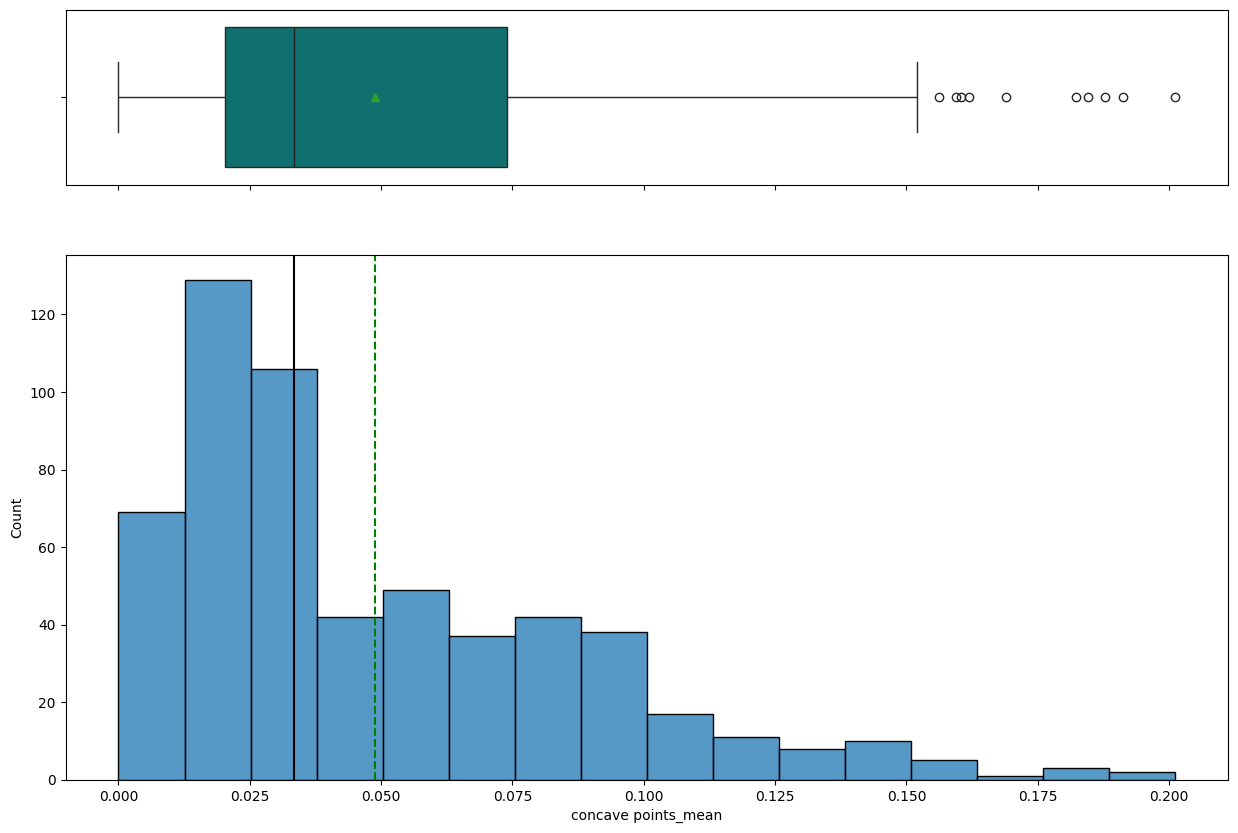

In [ ]:
histogram_boxplot(clean_data, "concave points_mean")

- The combined histogram and boxplot for concave points_mean display a distinctly positively skewed (right-skewed) distribution. The overwhelming majority of the values are concentrated in the lower range, specifically between 0.000 and 0.050. The mean (dashed green line) is visibly pulled to the right of the median (solid line) due to the long tail. Furthermore, the boxplot identifies several extreme outliers stretching out towards the 0.200 mark.

#### Observation on symmetry_mean :-

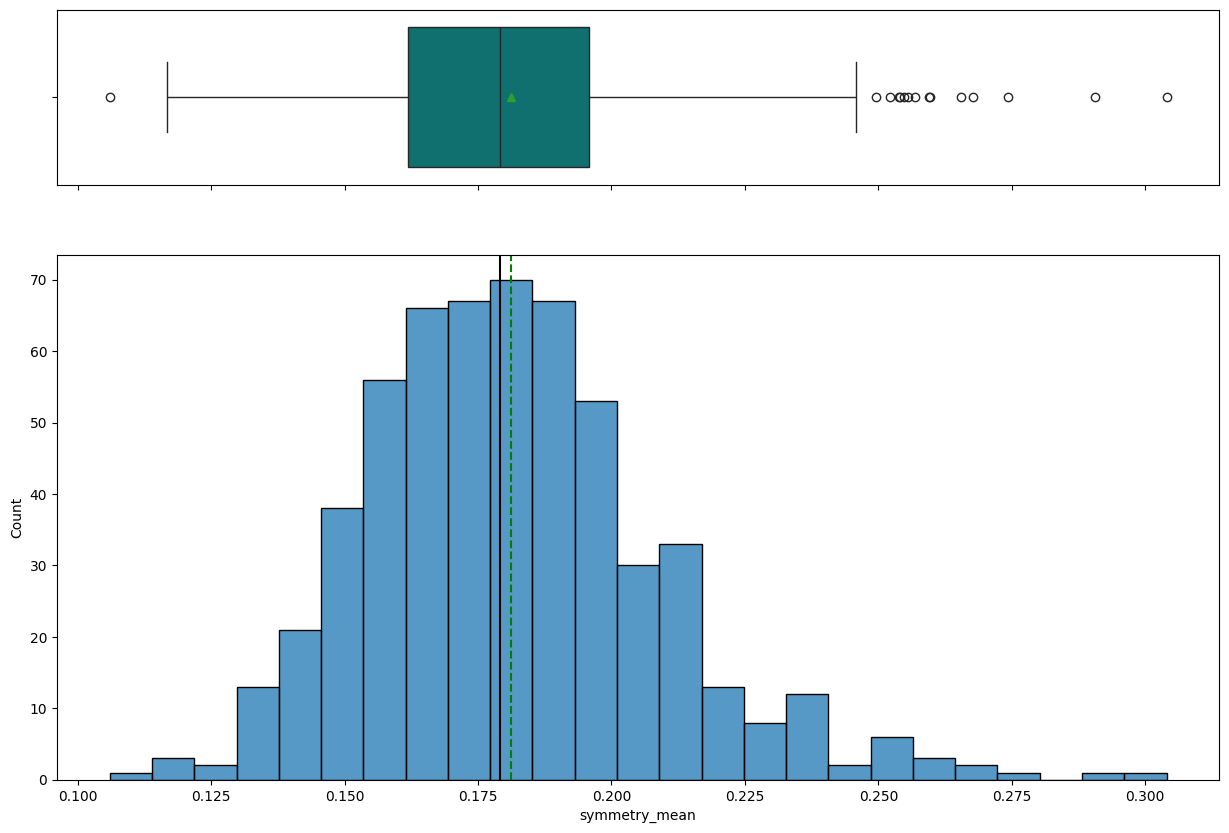

In [ ]:
histogram_boxplot(clean_data, "symmetry_mean")

- The combined histogram and boxplot for symmetry_mean reveal a nearly normal (bell-shaped) distribution with a very slight right skew.  The majority of the data is symmetrically centered between 0.150 and 0.200, causing the mean (dashed line) and median (solid line) to be closely aligned. However, the boxplot indicates the presence of outliers on both ends, with a more pronounced cluster of extreme values on the higher end extending towards 0.300.

#### Observation on fractal_dimension_mean :-

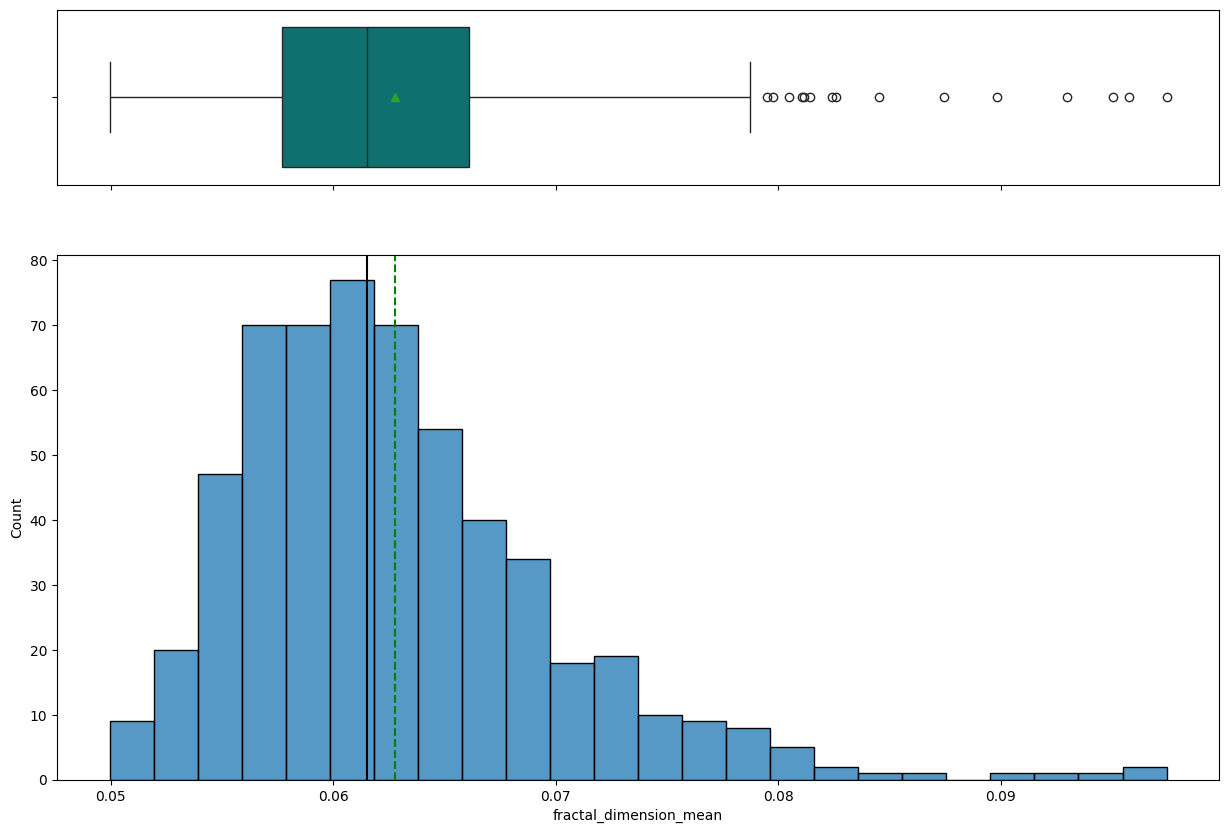

In [ ]:
histogram_boxplot(clean_data, "fractal_dimension_mean")

- The combined histogram and boxplot for fractal_dimension_mean illustrate a clear right-skewed (positively skewed) distribution. The bulk of the data is tightly packed in a very narrow range, primarily between 0.055 and 0.065. Consequently, the mean (dashed line) is slightly pulled to the right of the median (solid line). The boxplot uncovers a long sequence of extreme outliers on the higher end, extending up to approximately 0.095.

#### Observation on radius_se :-

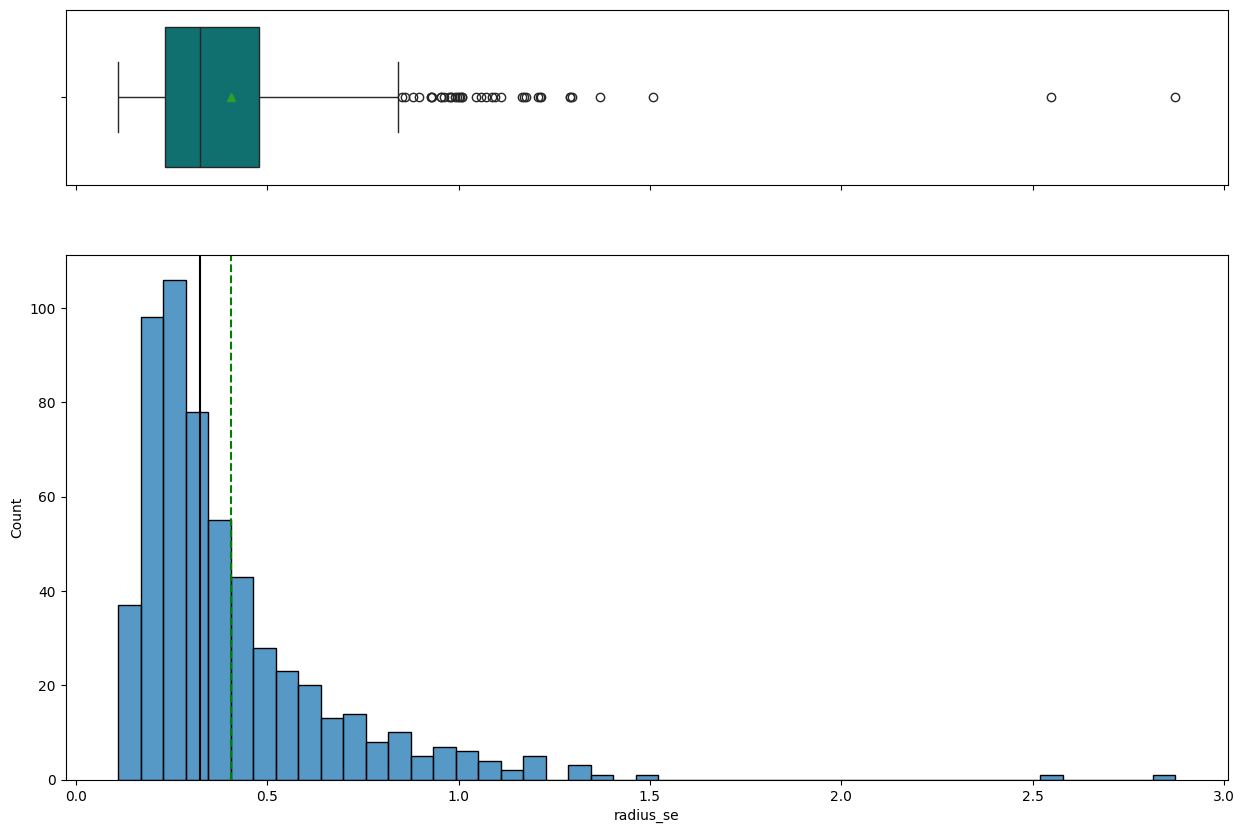

In [ ]:
histogram_boxplot(clean_data, "radius_se")

- The combined histogram and boxplot for radius_se demonstrate a severely right-skewed (positively skewed) distribution. The vast majority of the standard error values are heavily concentrated at the lower end, typically between 0.1 and 0.5. Because of this heavy skewness, the mean (dashed line) is pulled significantly to the right of the median (solid line). Furthermore, the boxplot exposes a very long, dense trail of extreme outliers, with some values stretching far out to the 2.5 and 3.0 marks.

#### Observation on texture_se :-

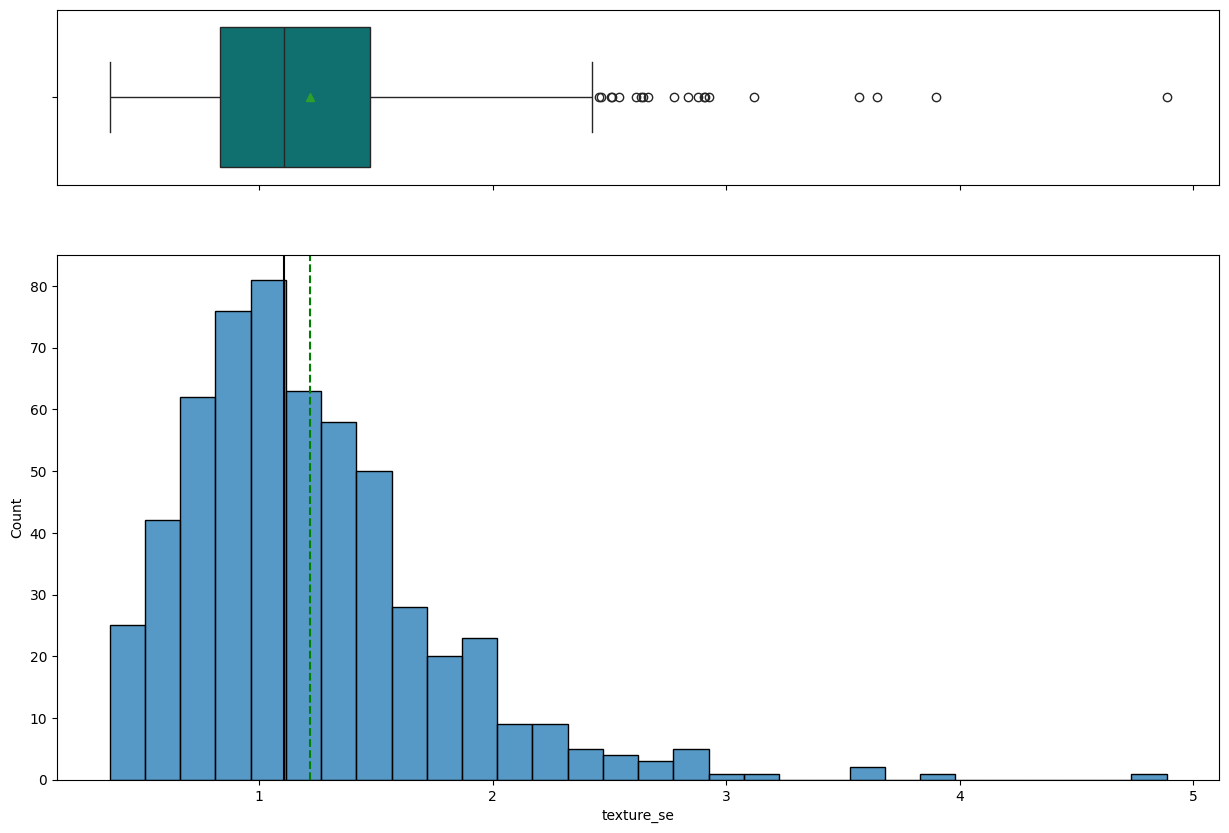

In [ ]:
histogram_boxplot(clean_data, "texture_se")

- The combined histogram and boxplot for texture_se illustrate a distinctly right-skewed (positively skewed) distribution. The bulk of the data is heavily concentrated in the lower range, approximately between 0.5 and 1.5. Due to this skewness, the mean (dashed line) is pulled noticeably to the right of the median (solid line). The boxplot reveals a long, sparse trail of extreme outliers extending towards the higher end, reaching up to almost 5.0.

#### Observation on perimeter_se :-

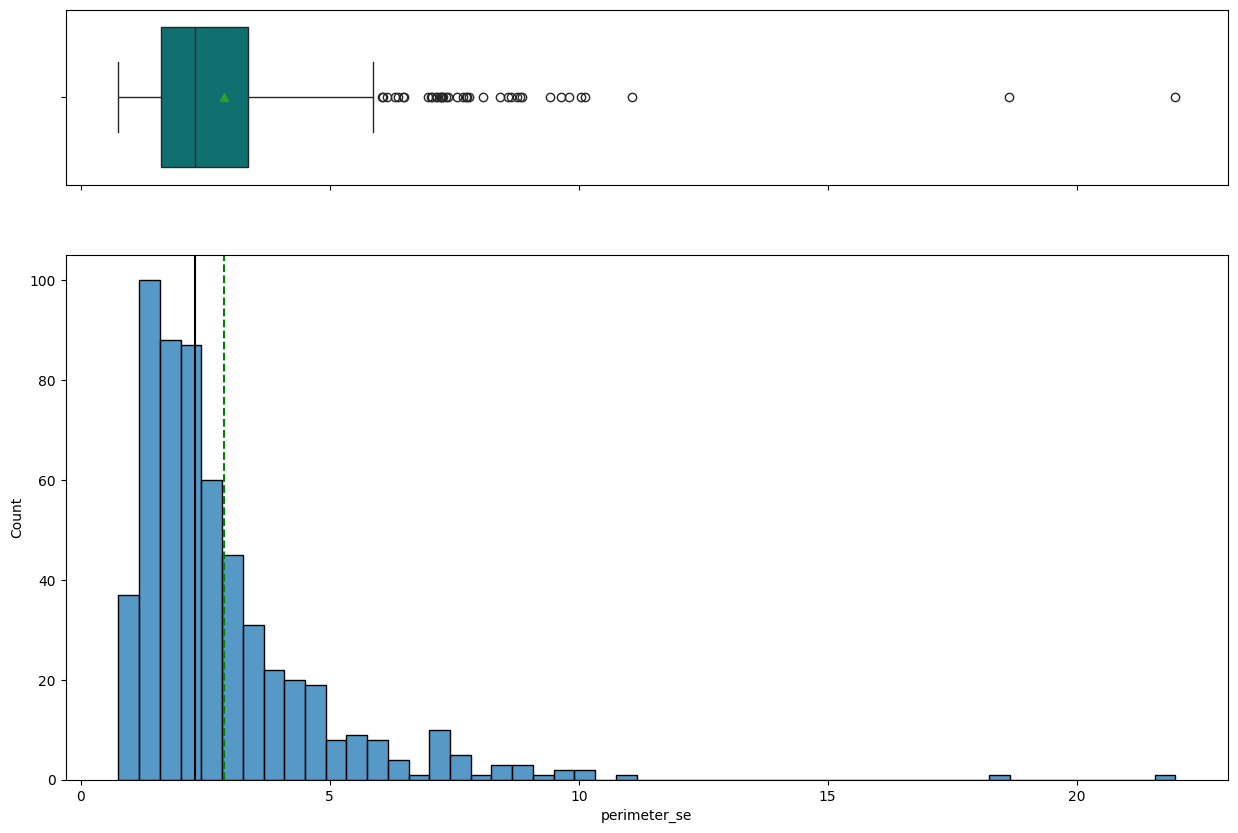

In [ ]:
histogram_boxplot(clean_data, "perimeter_se")

- The combined histogram and boxplot for perimeter_se display a highly right-skewed (positively skewed) distribution.  The majority of the standard error values are densely packed at the lower end, typically between 1 and 4. Consequently, the mean (dashed line) is significantly pulled to the right of the median (solid line). The boxplot reveals a long, continuous trail of extreme outliers, with some extreme values reaching up to approximately 22.

#### Observation on area_se :-

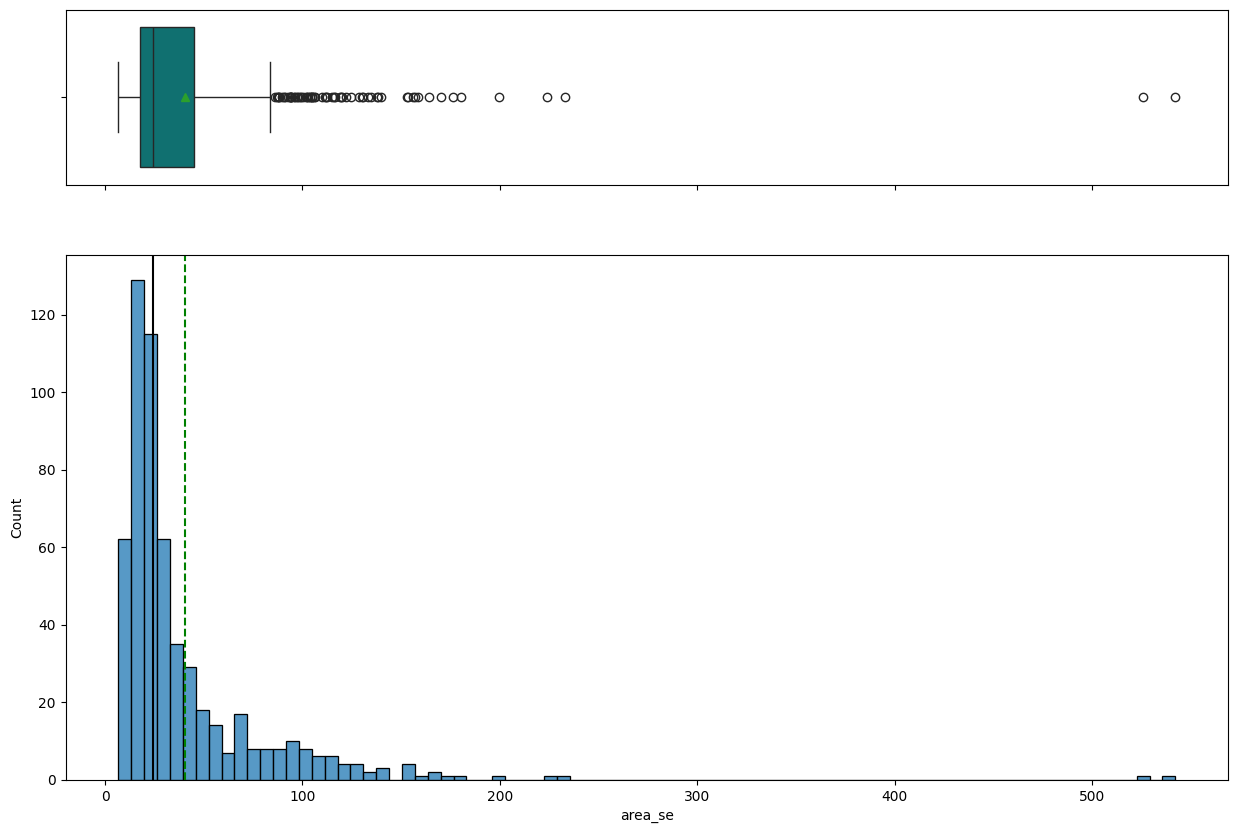

In [ ]:
histogram_boxplot(clean_data, "area_se")

- The combined histogram and boxplot for area_se reveal a severely right-skewed (positively skewed) distribution. The vast majority of the data is densely concentrated in the lower range, typically between 0 and 50. Due to this extreme skewness, the mean (dashed line) is significantly pulled to the right of the median (solid line). The boxplot displays a massive and dense tail of extreme outliers, with maximum values stretching beyond the 500 mark.

#### Observation on smoothness_se :-

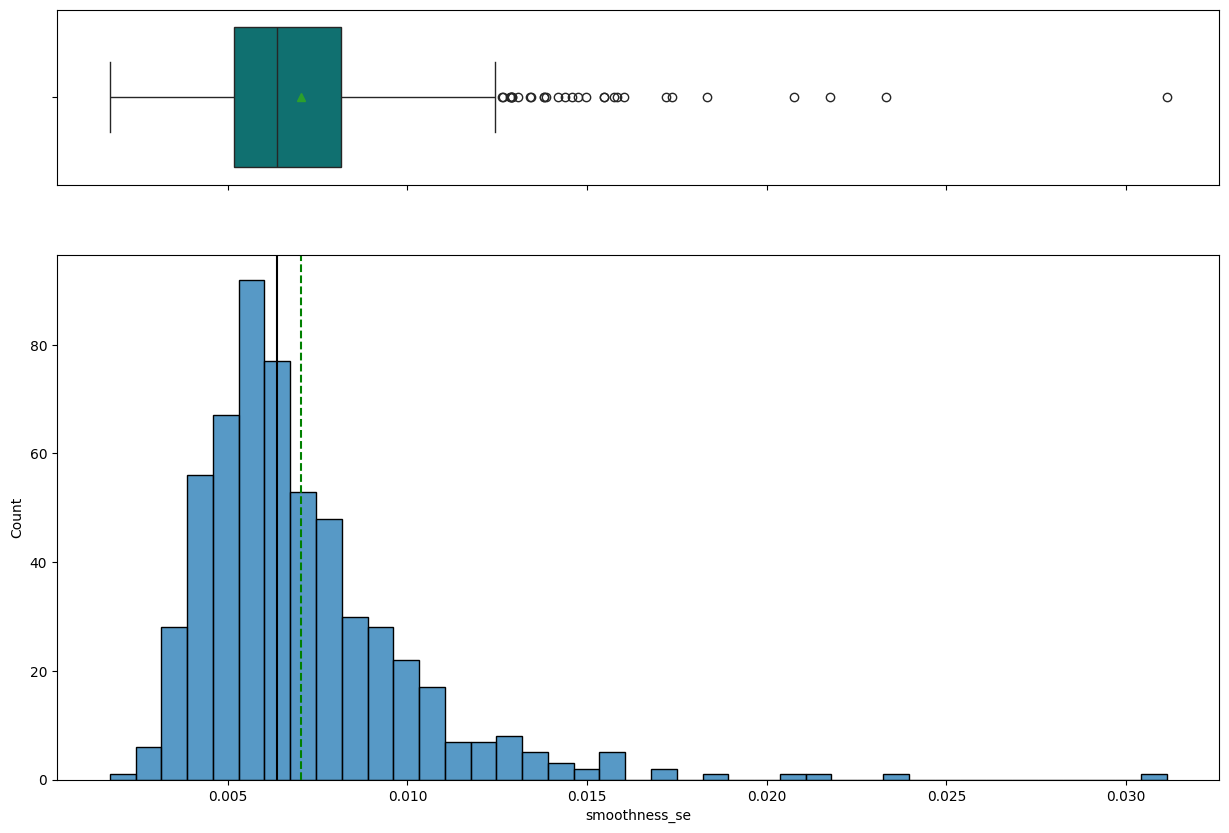

In [ ]:
histogram_boxplot(clean_data, "smoothness_se")

- The combined histogram and boxplot for smoothness_se reveal a distinctly right-skewed (positively skewed) distribution.  The vast majority of the standard error values are densely clustered at the extreme lower end, primarily between 0.004 and 0.010. Due to this right-sided tail, the mean (dashed line) is pulled noticeably to the right of the median (solid line). The boxplot also highlights a prominent trail of extreme outliers stretching out towards the 0.030 mark.

#### Observation on compactness_se :-

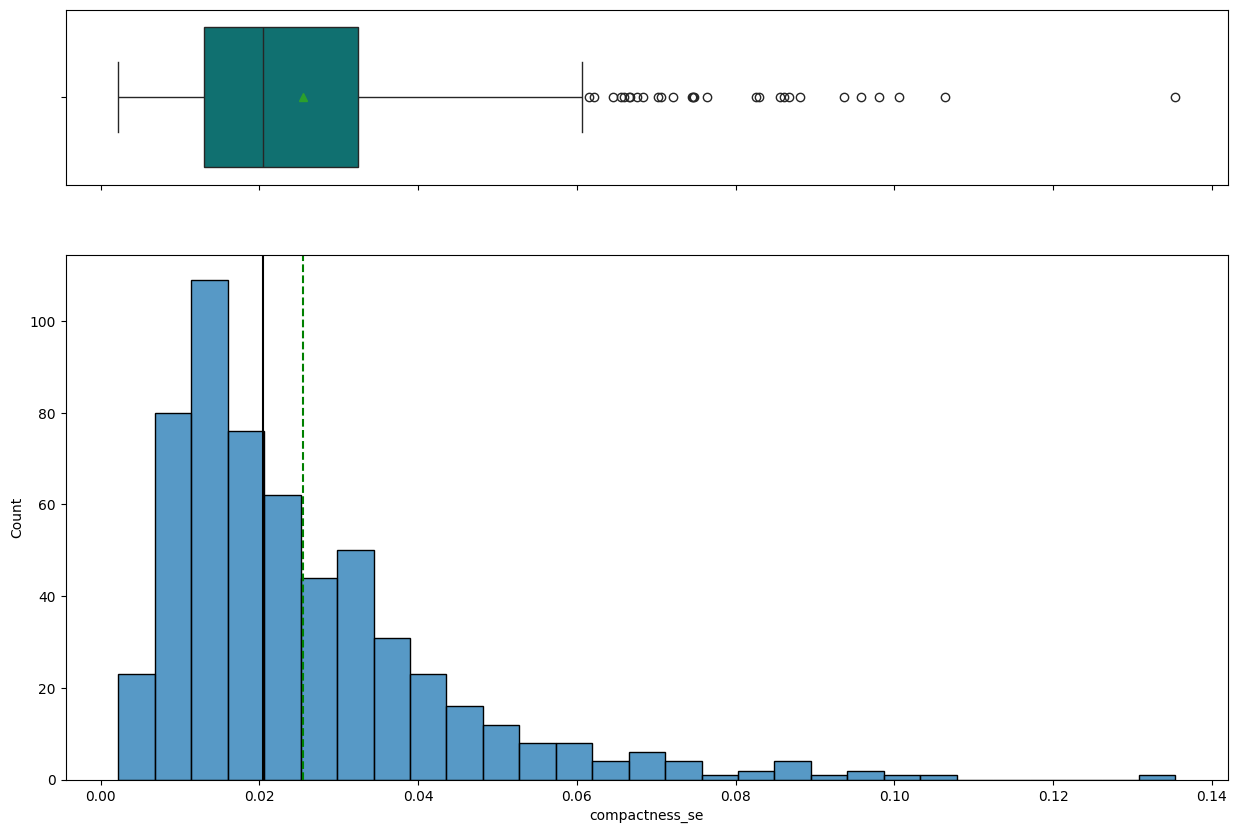

In [ ]:
histogram_boxplot(clean_data, "compactness_se")

- The combined histogram and boxplot for compactness_se illustrate a strongly right-skewed (positively skewed) distribution.  The vast majority of the standard error values are densely clustered at the lower end, predominantly between 0.01 and 0.04. Due to this heavy skewness, the mean (dashed line) is significantly pulled to the right of the median (solid line). The boxplot highlights a long, sparse tail of extreme outliers, with maximum values extending up to approximately 0.14.

#### Observation on concavity_se :-

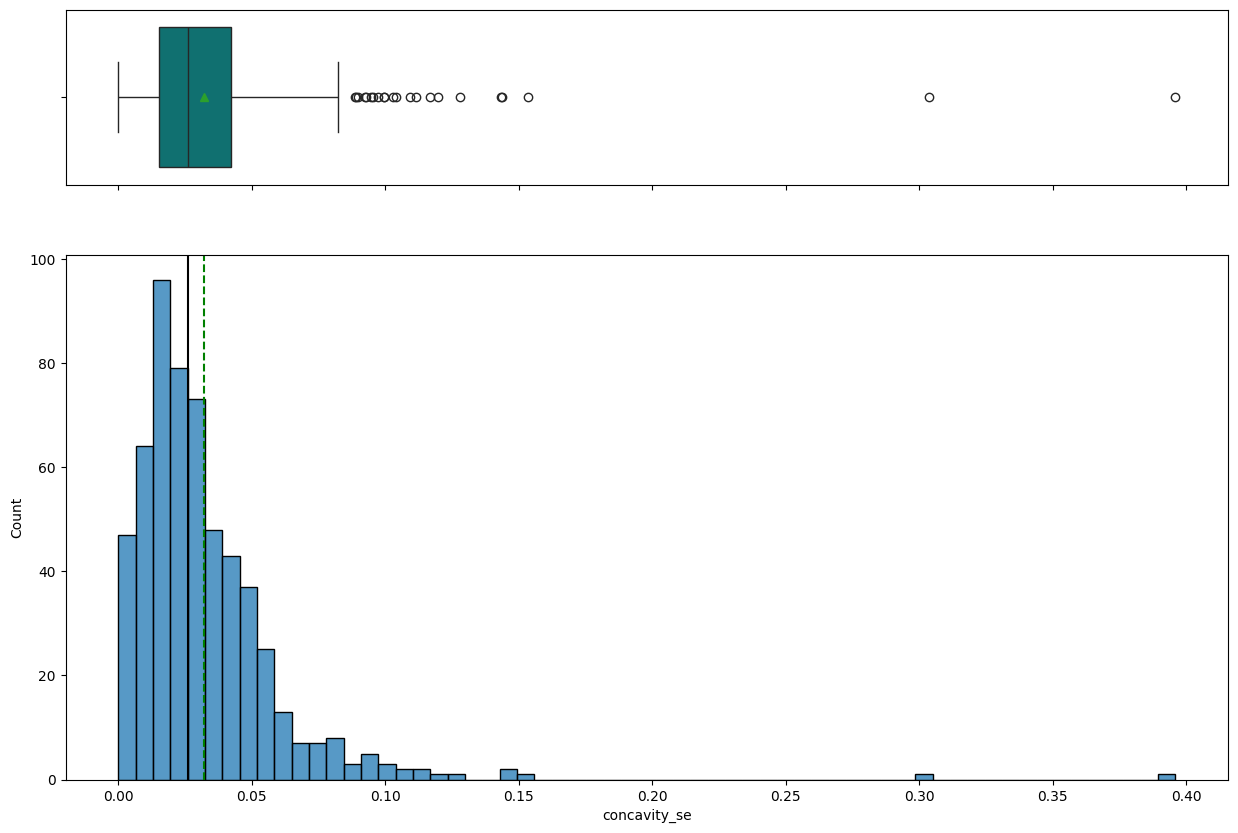

In [ ]:
histogram_boxplot(clean_data, "concavity_se")

- The combined histogram and boxplot for concavity_se exhibit a highly right-skewed (positively skewed) distribution. The vast majority of the standard error values are densely concentrated at the extreme lower end, primarily between 0.00 and 0.05. Because of this heavy skewness, the mean (dashed line) is significantly pulled to the right of the median (solid line). The boxplot highlights a prominent, trailing line of extreme outliers, with maximum values extending up to approximately 0.40.

#### Observation on concave points_se :-

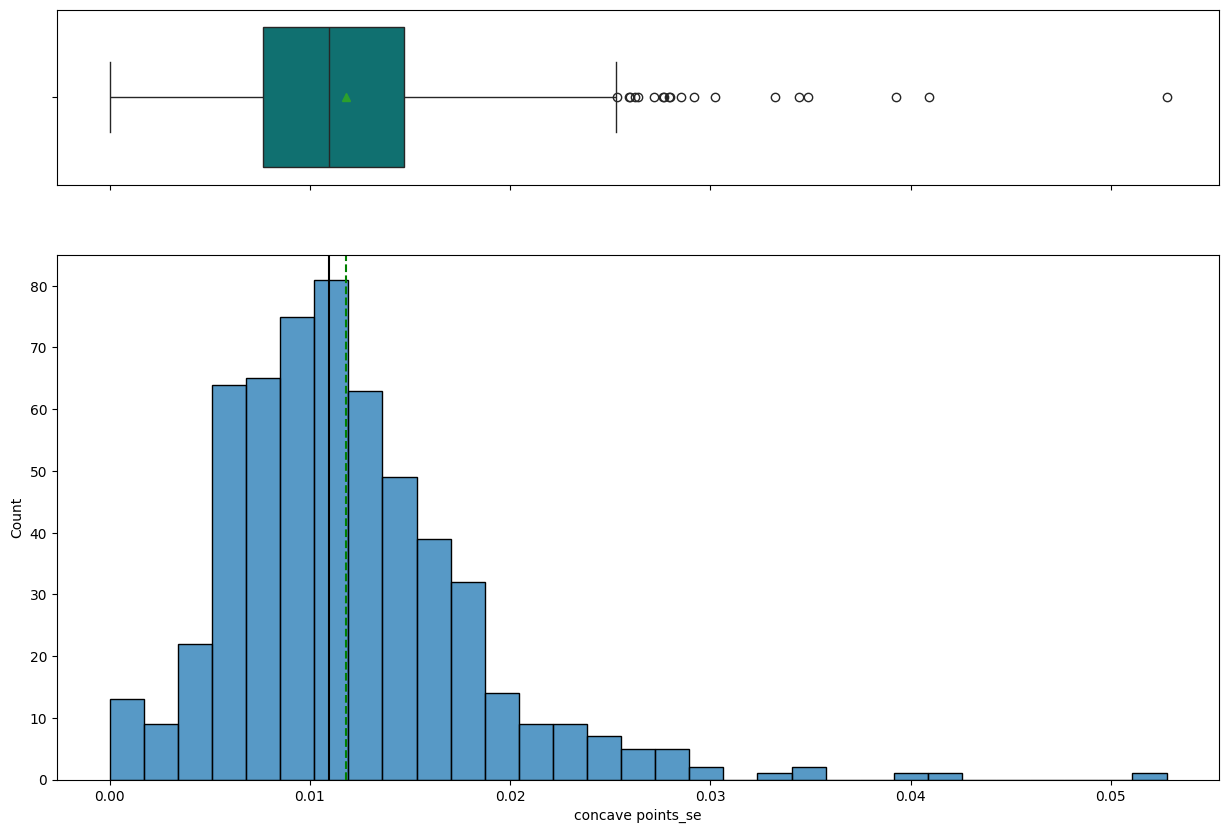

In [ ]:
histogram_boxplot(clean_data, "concave points_se")

- The combined histogram and boxplot for concave points_se display a noticeable right-skewed (positively skewed) distribution. The majority of the standard error values are concentrated in a very narrow, low range, primarily between 0.005 and 0.015. Consequently, the mean (dashed line) is pulled slightly to the right of the median (solid line). The boxplot reveals a scattered trail of outliers on the higher end, with extreme values extending up to approximately 0.05.

#### Observation on symmetry_se :-

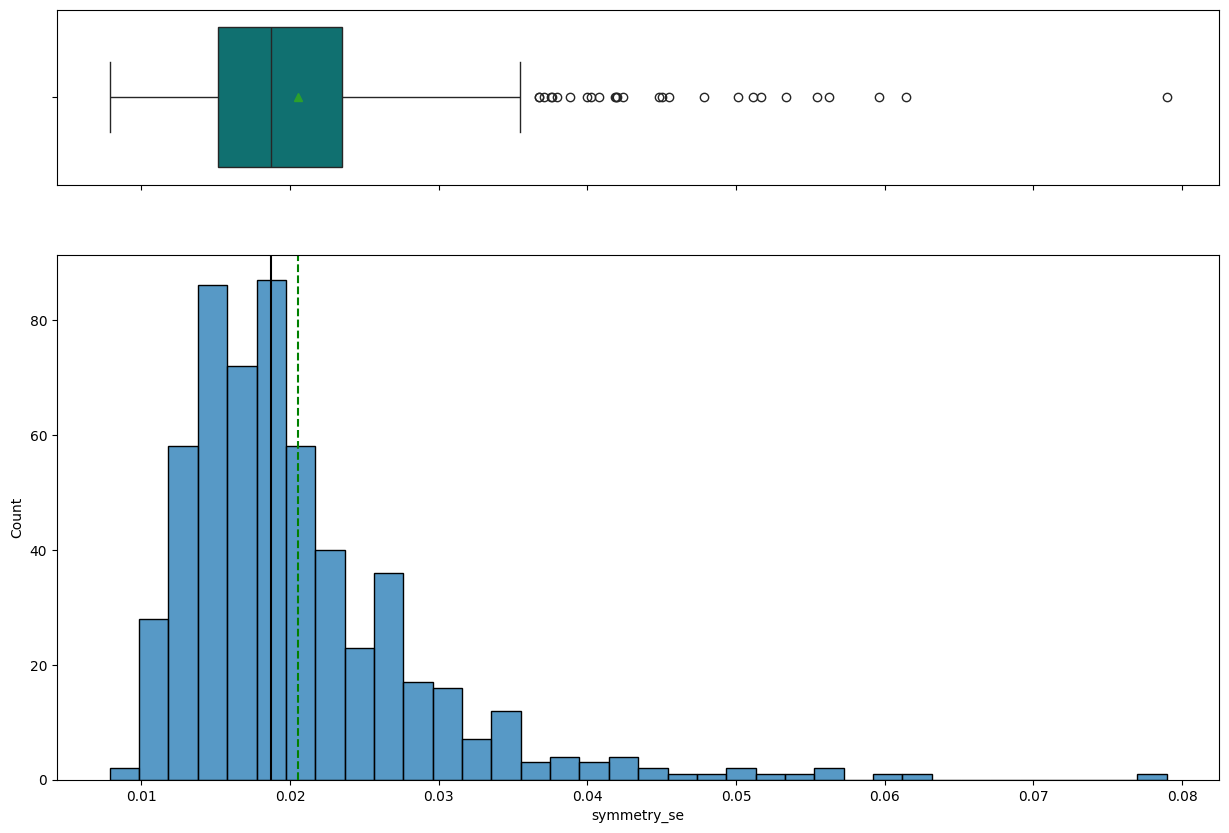

In [ ]:
histogram_boxplot(clean_data, "symmetry_se")

- The combined histogram and boxplot for symmetry_se display a clear right-skewed (positively skewed) distribution. The majority of the standard error values are concentrated in a low, narrow range, primarily between 0.01 and 0.03. Due to this skewness, the mean (dashed line) is pulled slightly to the right of the median (solid line). The boxplot highlights a scattered trail of outliers on the higher end, with values extending up to approximately 0.08.

#### Observation on fractal_dimension_se :-

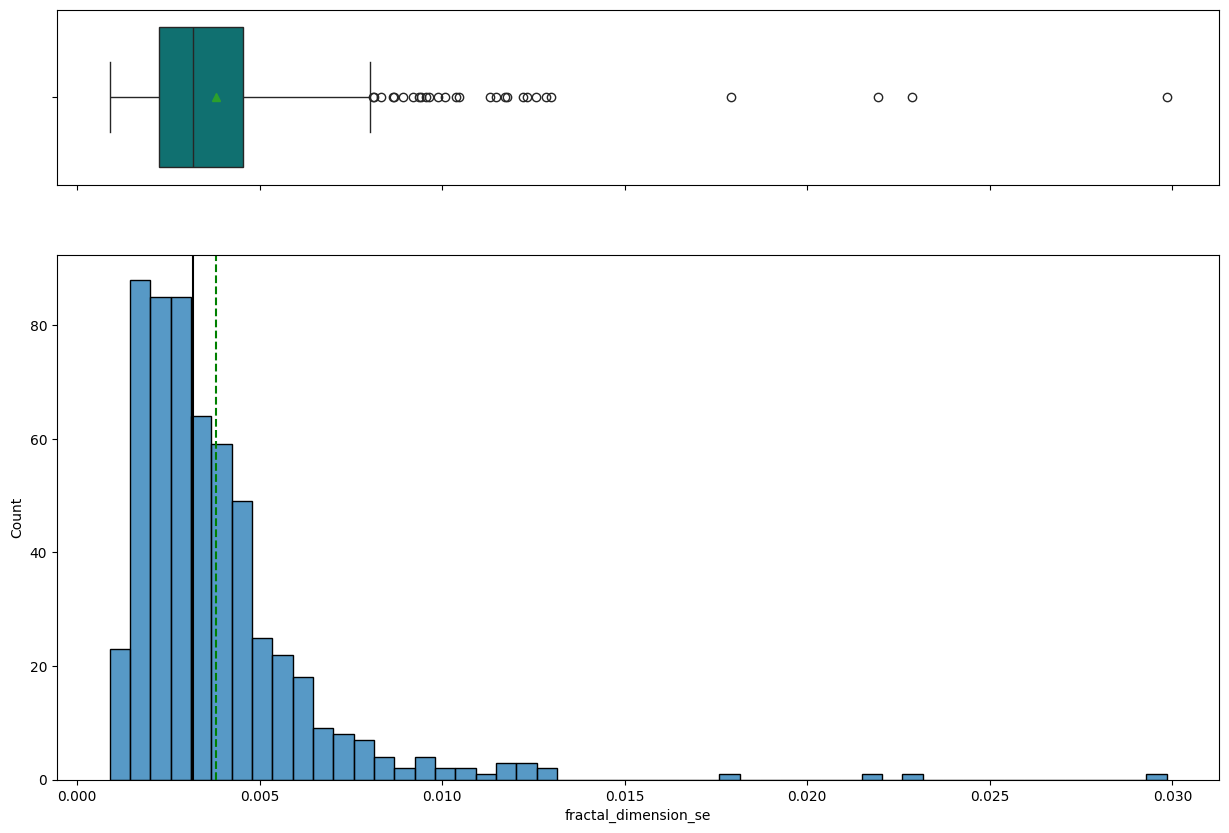

In [ ]:
histogram_boxplot(clean_data, "fractal_dimension_se")

- The combined histogram and boxplot for fractal_dimension_se illustrate a highly right-skewed (positively skewed) distribution. The vast majority of the standard error values are densely clustered at a microscopic scale, primarily between 0.002 and 0.005. Due to this extreme skewness, the mean (dashed line) is significantly pulled to the right of the median (solid line). The boxplot reveals a long, sparse tail of extreme outliers, with maximum values extending up to approximately 0.030.

#### Observation on radius_worst :-

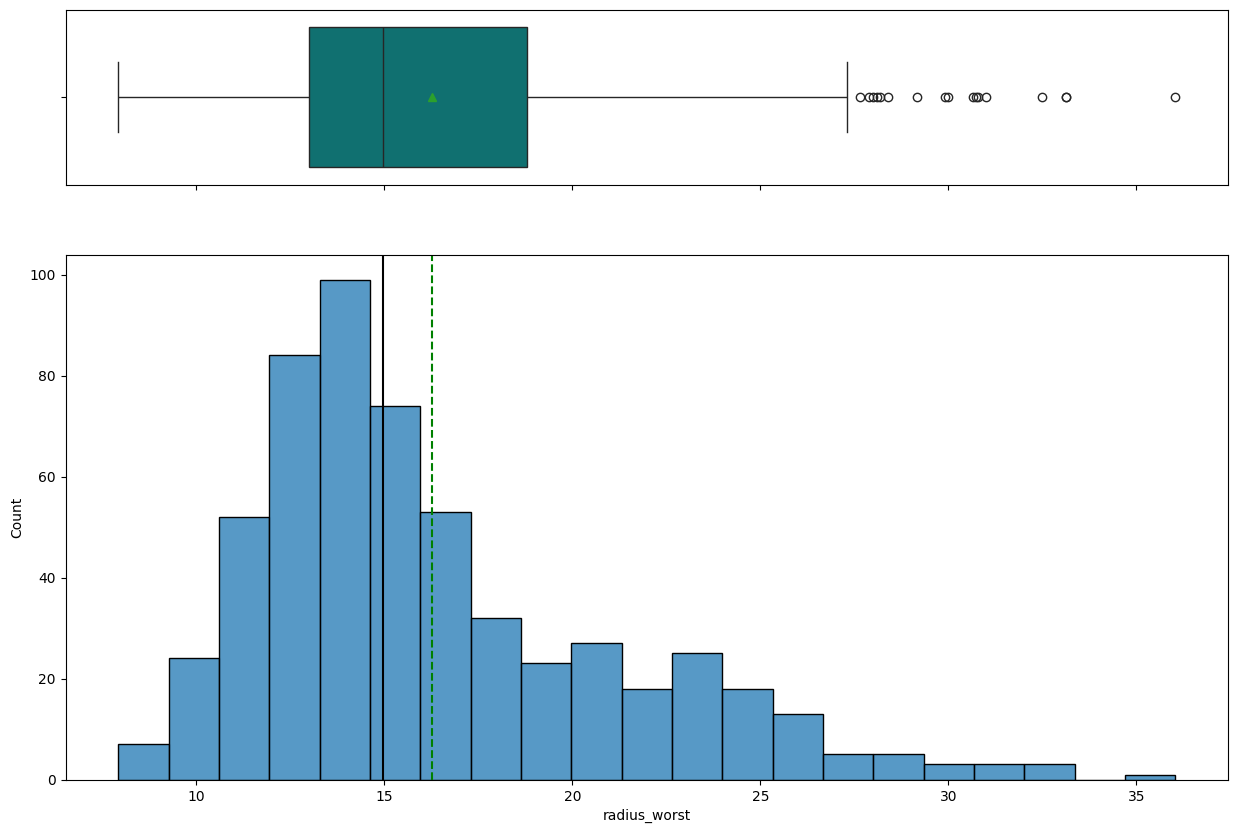

In [ ]:
histogram_boxplot(clean_data, "radius_worst")

- The combined histogram and boxplot for radius_worst reveal a moderately right-skewed (positively skewed) distribution. The bulk of the data points are concentrated between the values of 12 and 17. Consistent with a right skew, the mean (dashed line) is shifted to the right of the median (solid line). The boxplot clearly indicates the presence of multiple outliers on the higher end, with values extending from roughly 25 up to 36.

#### Observation on texture_worst :-

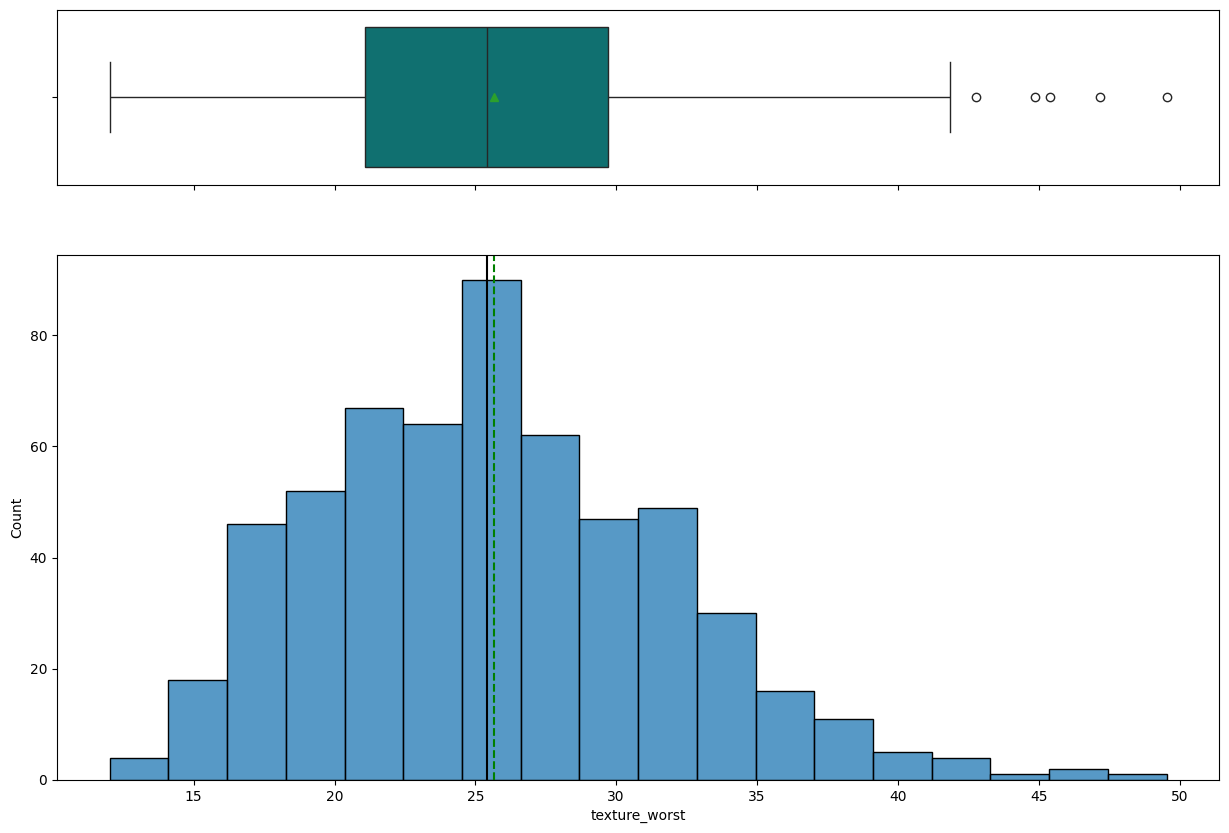

In [ ]:
histogram_boxplot(clean_data, "texture_worst")

- The combined histogram and boxplot for texture_worst exhibit an approximately normal (symmetrical) distribution with a very slight rightward skew. The majority of the data values are centrally clustered between 20 and 30. Because the distribution is nearly normal, the mean (dashed line) and median (solid line) are closely aligned, right around the 25 mark. However, the boxplot identifies a few outliers on the higher end, extending beyond 40.

#### Observation on perimeter_worst :-

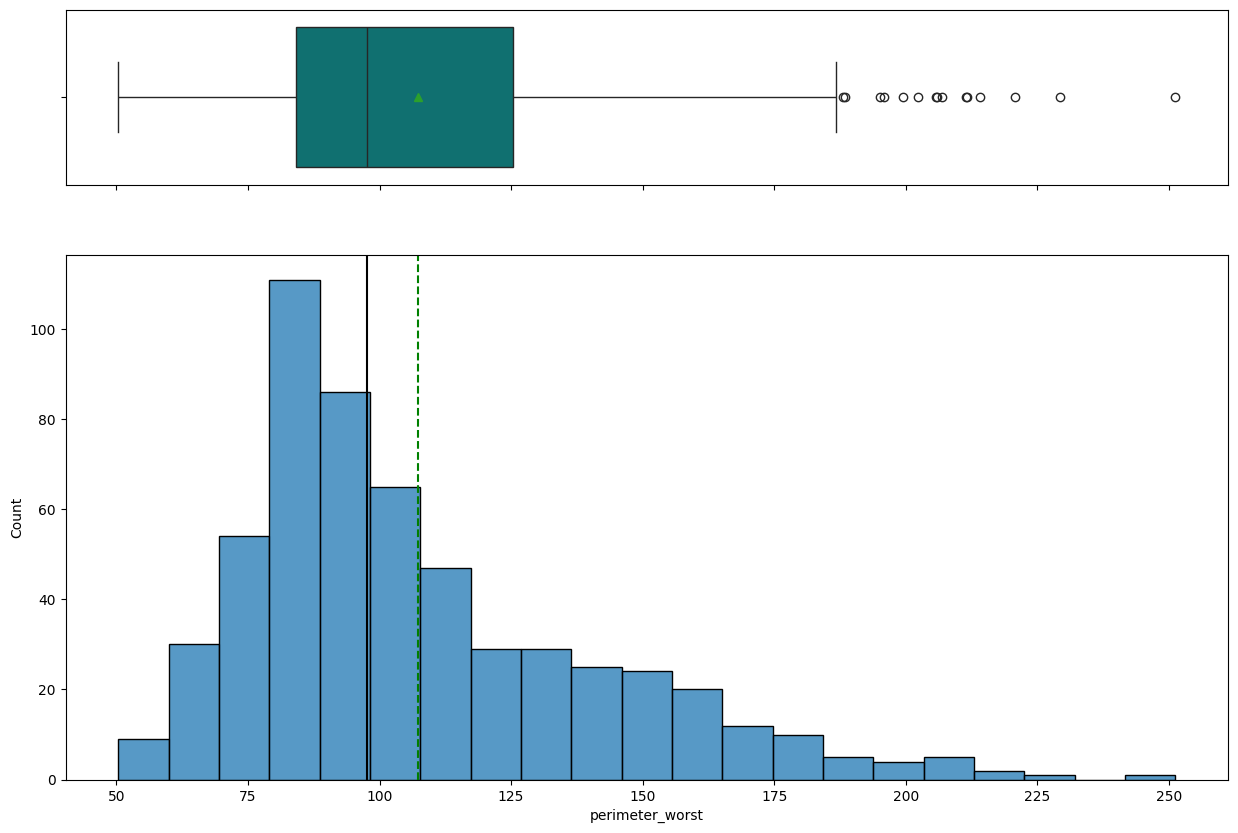

In [ ]:
histogram_boxplot(clean_data, "perimeter_worst")

- The combined histogram and boxplot for perimeter_worst exhibit a distinctly right-skewed (positively skewed) distribution. The majority of the data points are densely clustered in the lower range, primarily between 70 and 110. As a result of this skewness, the mean (dashed green line) is pulled noticeably to the right of the median (solid black line). Furthermore, the boxplot clearly highlights a significant, trailing sequence of extreme outliers on the higher end, extending well up to the 250 mark.

#### Observation on area_worst :-

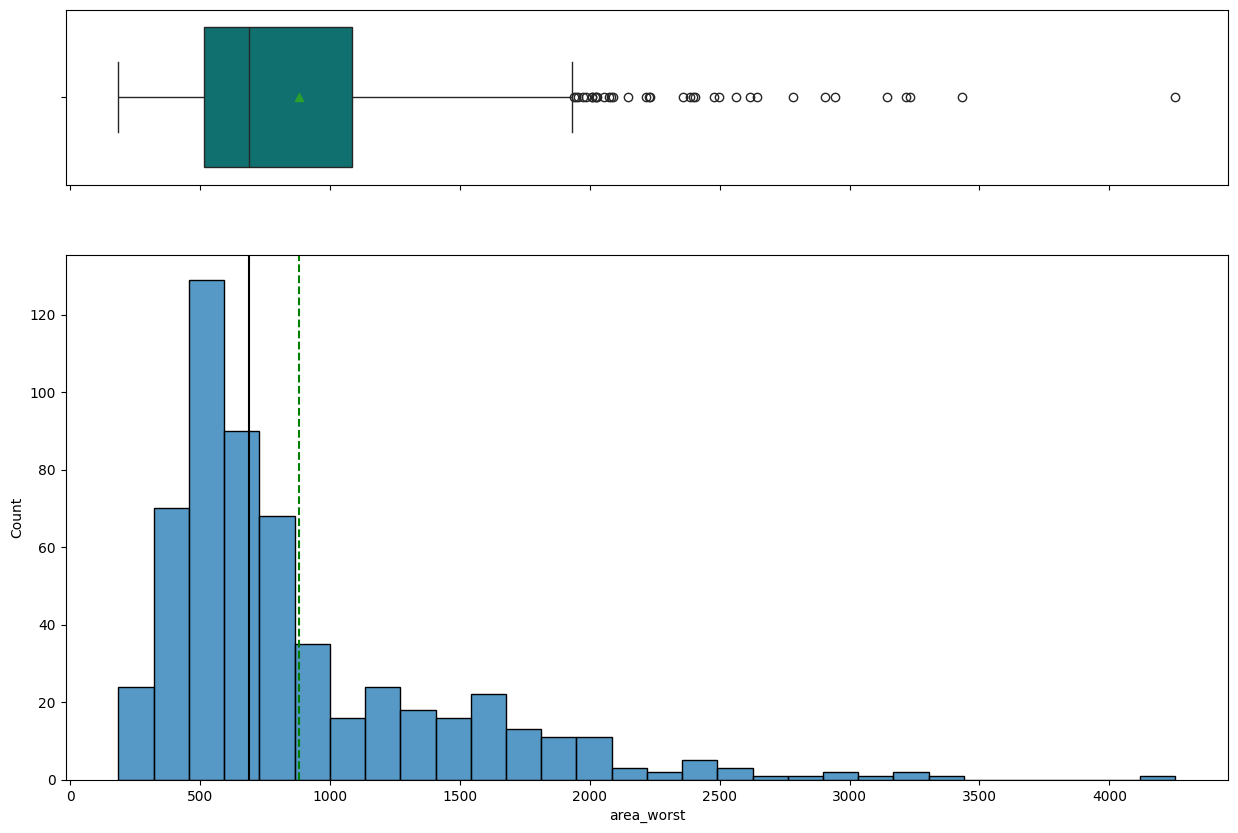

In [ ]:
histogram_boxplot(clean_data, "area_worst")

- The combined histogram and boxplot for area_worst reveal a severely right-skewed (positively skewed) distribution. The vast majority of the data points are densely clustered in the lower range, typically between 300 and 1000. Due to this extreme skewness, the mean (dashed green line) is pulled significantly to the right of the median (solid black line). The boxplot exposes a massive, trailing sequence of extreme outliers, with maximum values stretching far beyond the 4000 mark.

#### Observation on smoothness_worst :-

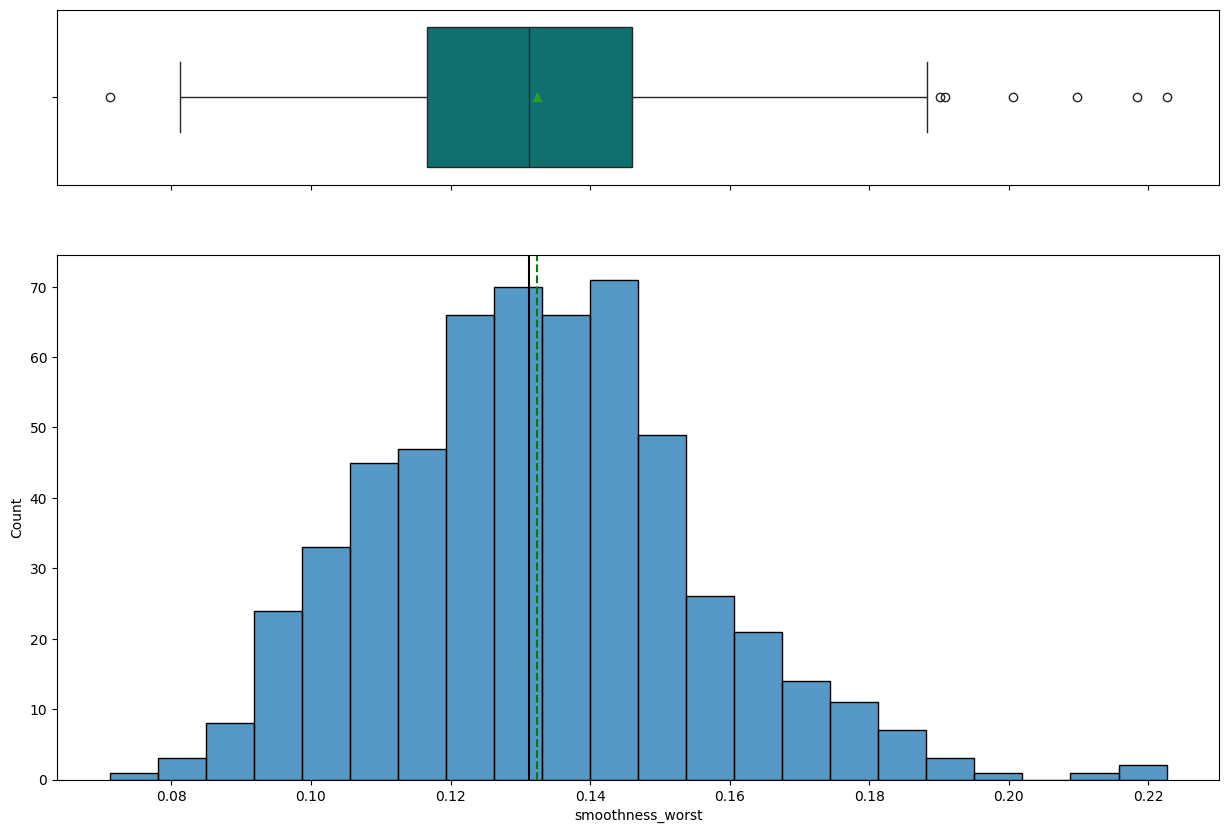

In [ ]:
histogram_boxplot(clean_data, "smoothness_worst")

- The combined histogram and boxplot for smoothness_worst exhibit an approximately normal (symmetrical) distribution  with a marginal rightward skew. The majority of the data values are centrally clustered between 0.11 and 0.16. Because the distribution is nearly symmetrical, the mean (dashed green line) and median (solid black line) are closely aligned around the 0.13 mark. The boxplot identifies a few minor outliers on the higher end, extending slightly beyond 0.20.

#### Observation on compactness_worst :-

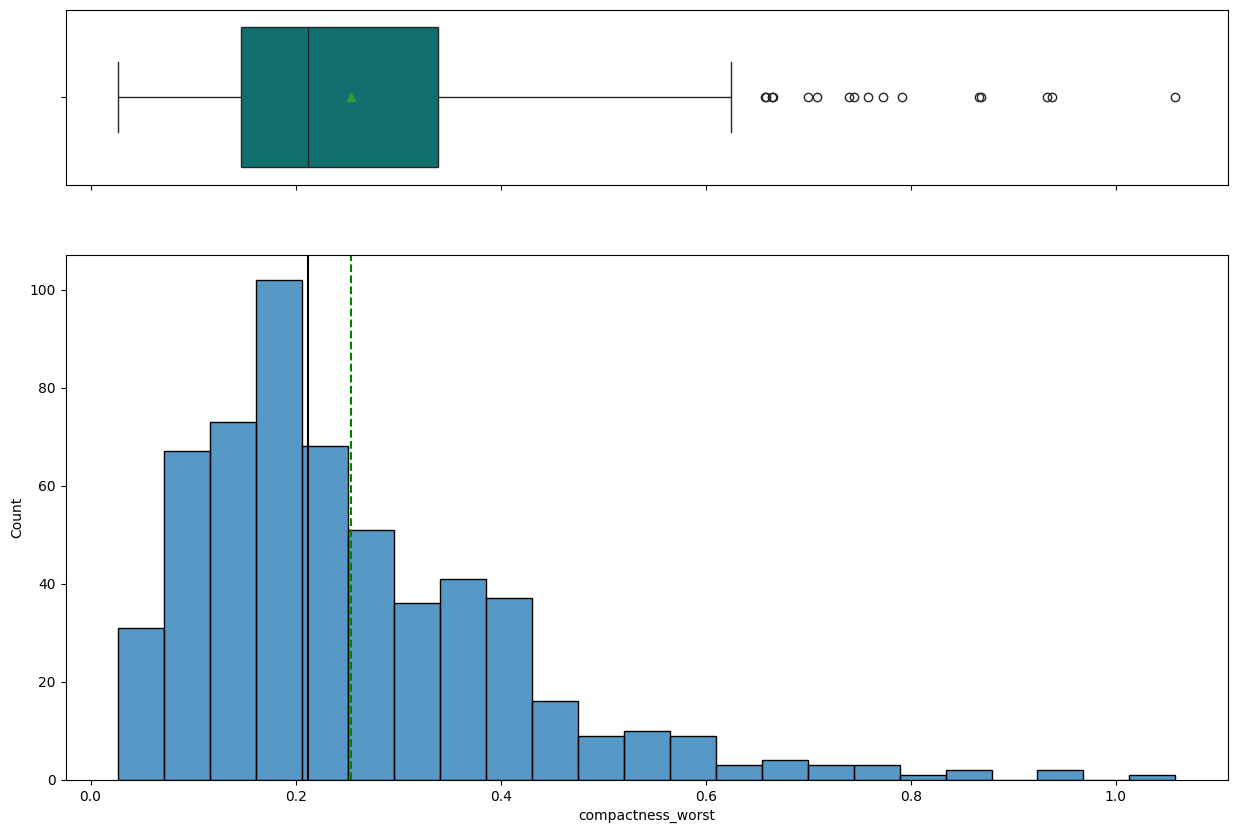

In [ ]:
histogram_boxplot(clean_data, "compactness_worst")

- The combined histogram and boxplot for compactness_worst display a distinctly right-skewed (positively skewed) distribution.  The bulk of the data is heavily concentrated in the lower range, primarily between 0.1 and 0.3. Due to this long right tail, the mean (dashed green line) is pulled noticeably to the right of the median (solid black line). Furthermore, the boxplot highlights a scattered trail of extreme outliers on the higher end, with maximum values extending beyond the 1.0 mark.

#### Observation on concavity_worst :-

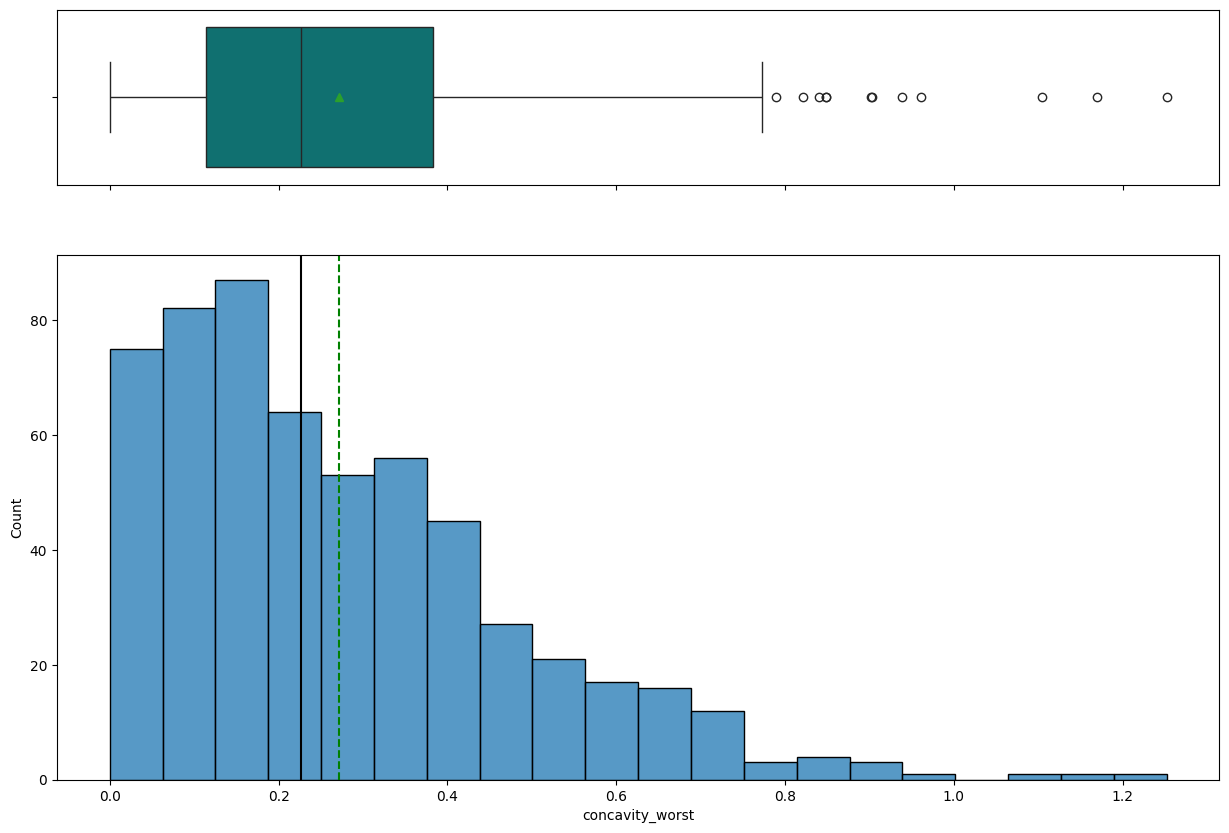

In [ ]:
histogram_boxplot(clean_data, "concavity_worst")

- The combined histogram and boxplot for concavity_worst display a prominent right-skewed (positively skewed) distribution.  The majority of the data points are densely concentrated in the lower range, primarily between 0.0 and 0.4. Because of this long rightward tail, the mean (dashed green line) is pulled noticeably to the right of the median (solid black line). Furthermore, the boxplot highlights a scattered trail of extreme outliers on the higher end, with maximum values extending up to approximately 1.2.

#### Observation on concave points_worst :-

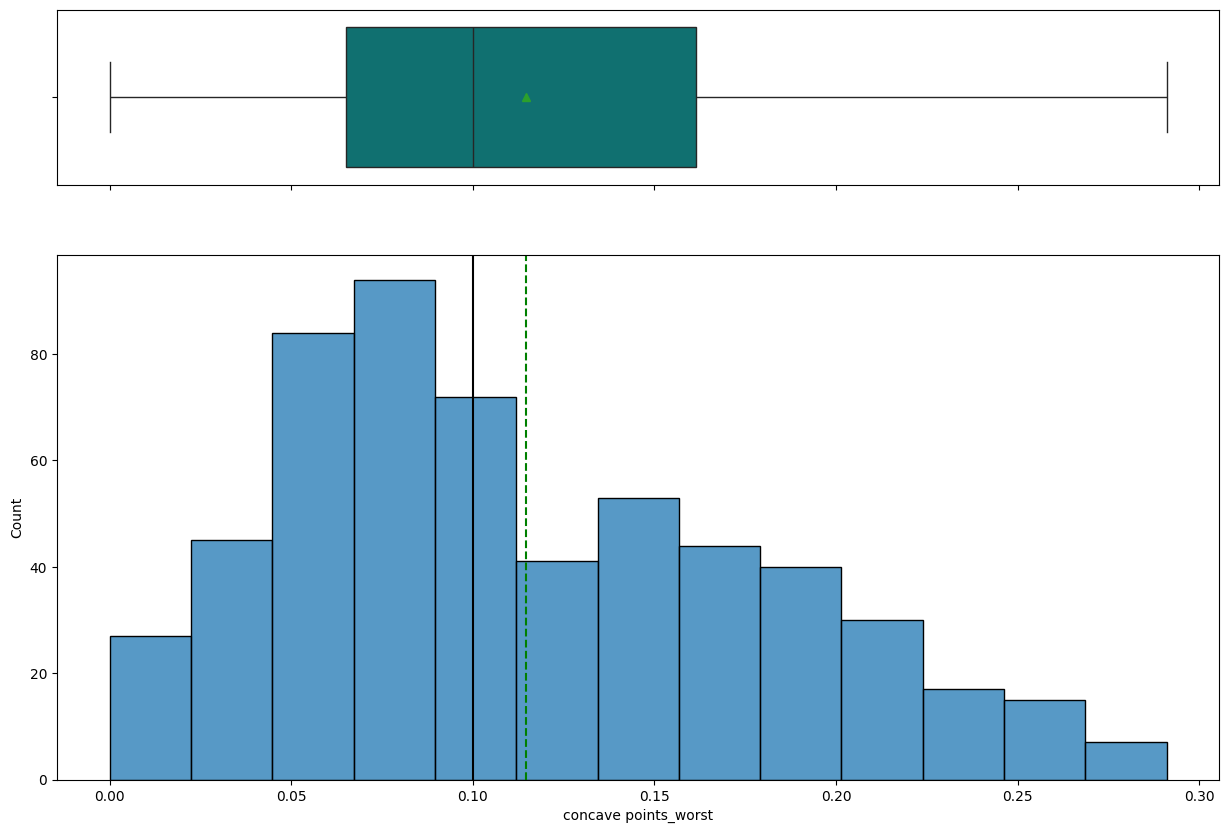

In [ ]:
histogram_boxplot(clean_data, "concave points_worst")

- The combined histogram and boxplot for concave points_worst display a mildly right-skewed (positively skewed) distribution. Unlike previous features in the _worst series, this boxplot shows no extreme outliers; the whiskers encompass the entire range of the data, which spans from 0.00 to approximately 0.29. The data points are fairly spread out, with a primary concentration between 0.05 and 0.15. Because of the mild skew, the mean (dashed green line) is only slightly pulled to the right of the median (solid black line).

#### Observation on symmetry_worst :-

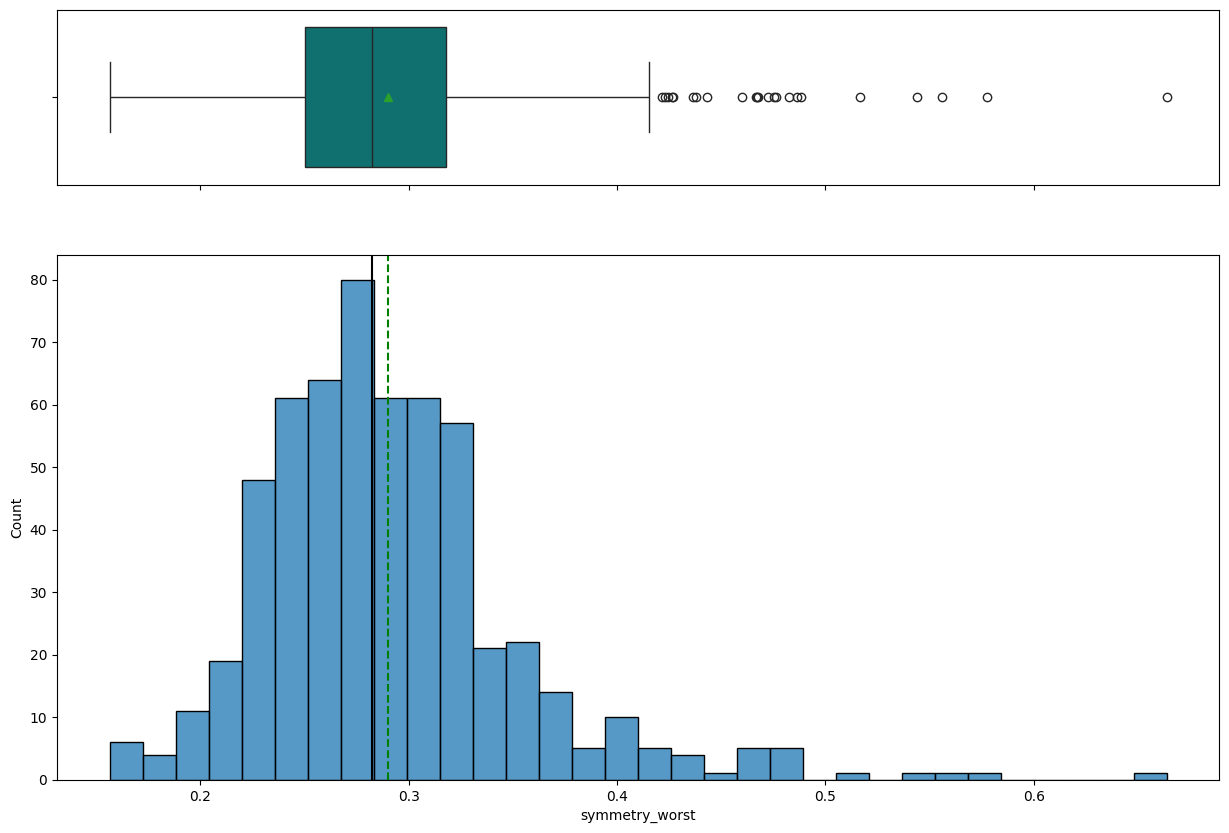

In [ ]:
histogram_boxplot(clean_data, "symmetry_worst")

- The combined histogram and boxplot for symmetry_worst display a distinctly right-skewed (positively skewed) distribution.  The bulk of the data points are densely concentrated in the lower range, primarily between 0.2 and 0.4. Due to this rightward tail, the mean (dashed green line) is pulled noticeably to the right of the median (solid black line). Furthermore, the boxplot highlights a scattered trail of extreme outliers on the higher end, with values extending beyond the 0.6 mark.

#### Observation on fractal_dimension_worst :-

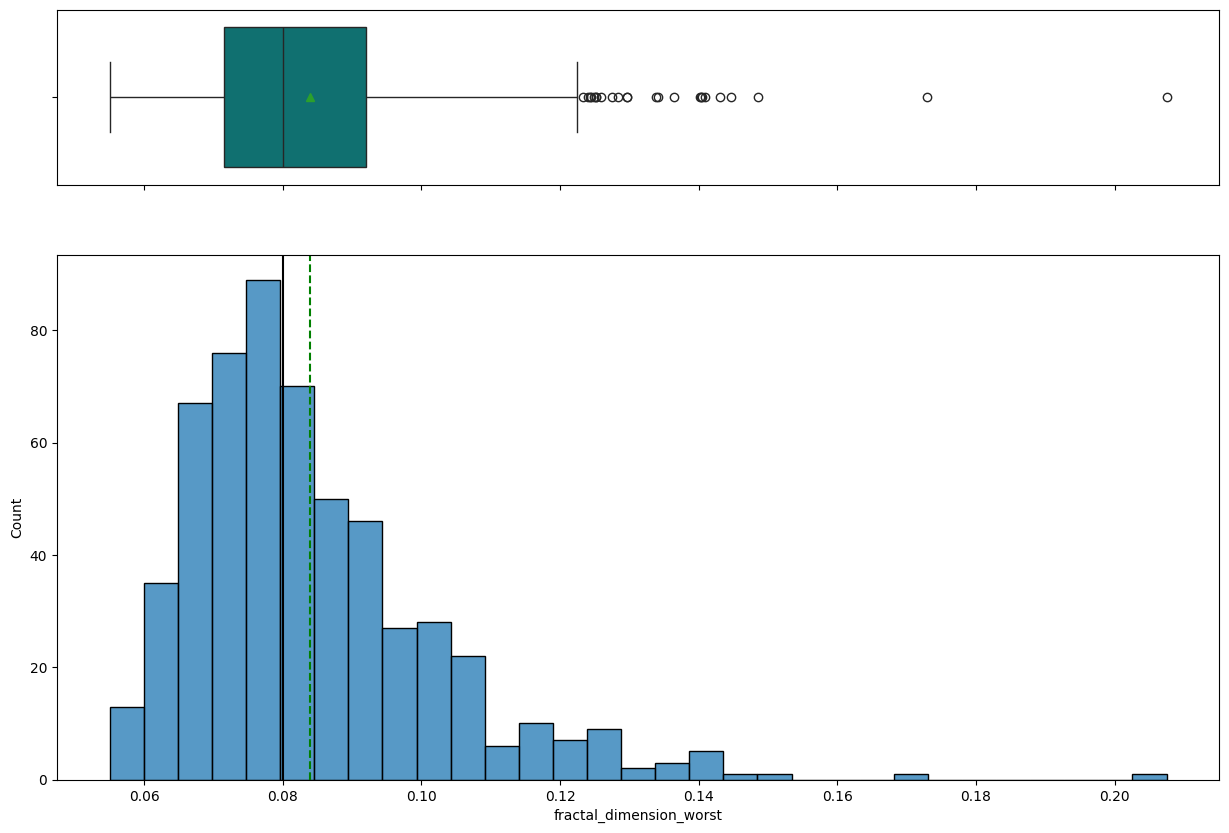

In [ ]:
histogram_boxplot(clean_data, "fractal_dimension_worst")

- The combined histogram and boxplot for fractal_dimension_worst illustrate a clear right-skewed (positively skewed) distribution. The vast majority of the data values are densely clustered at a microscopic scale, primarily between 0.06 and 0.10. Due to this rightward tail, the mean (dashed green line) is pulled slightly to the right of the median (solid black line). The boxplot reveals a long, sparse tail of extreme outliers on the higher end, with maximum values extending up to approximately 0.20.

### Bivariate analysis..

#### Correlation Heatmap on Breast Cancer Features :-

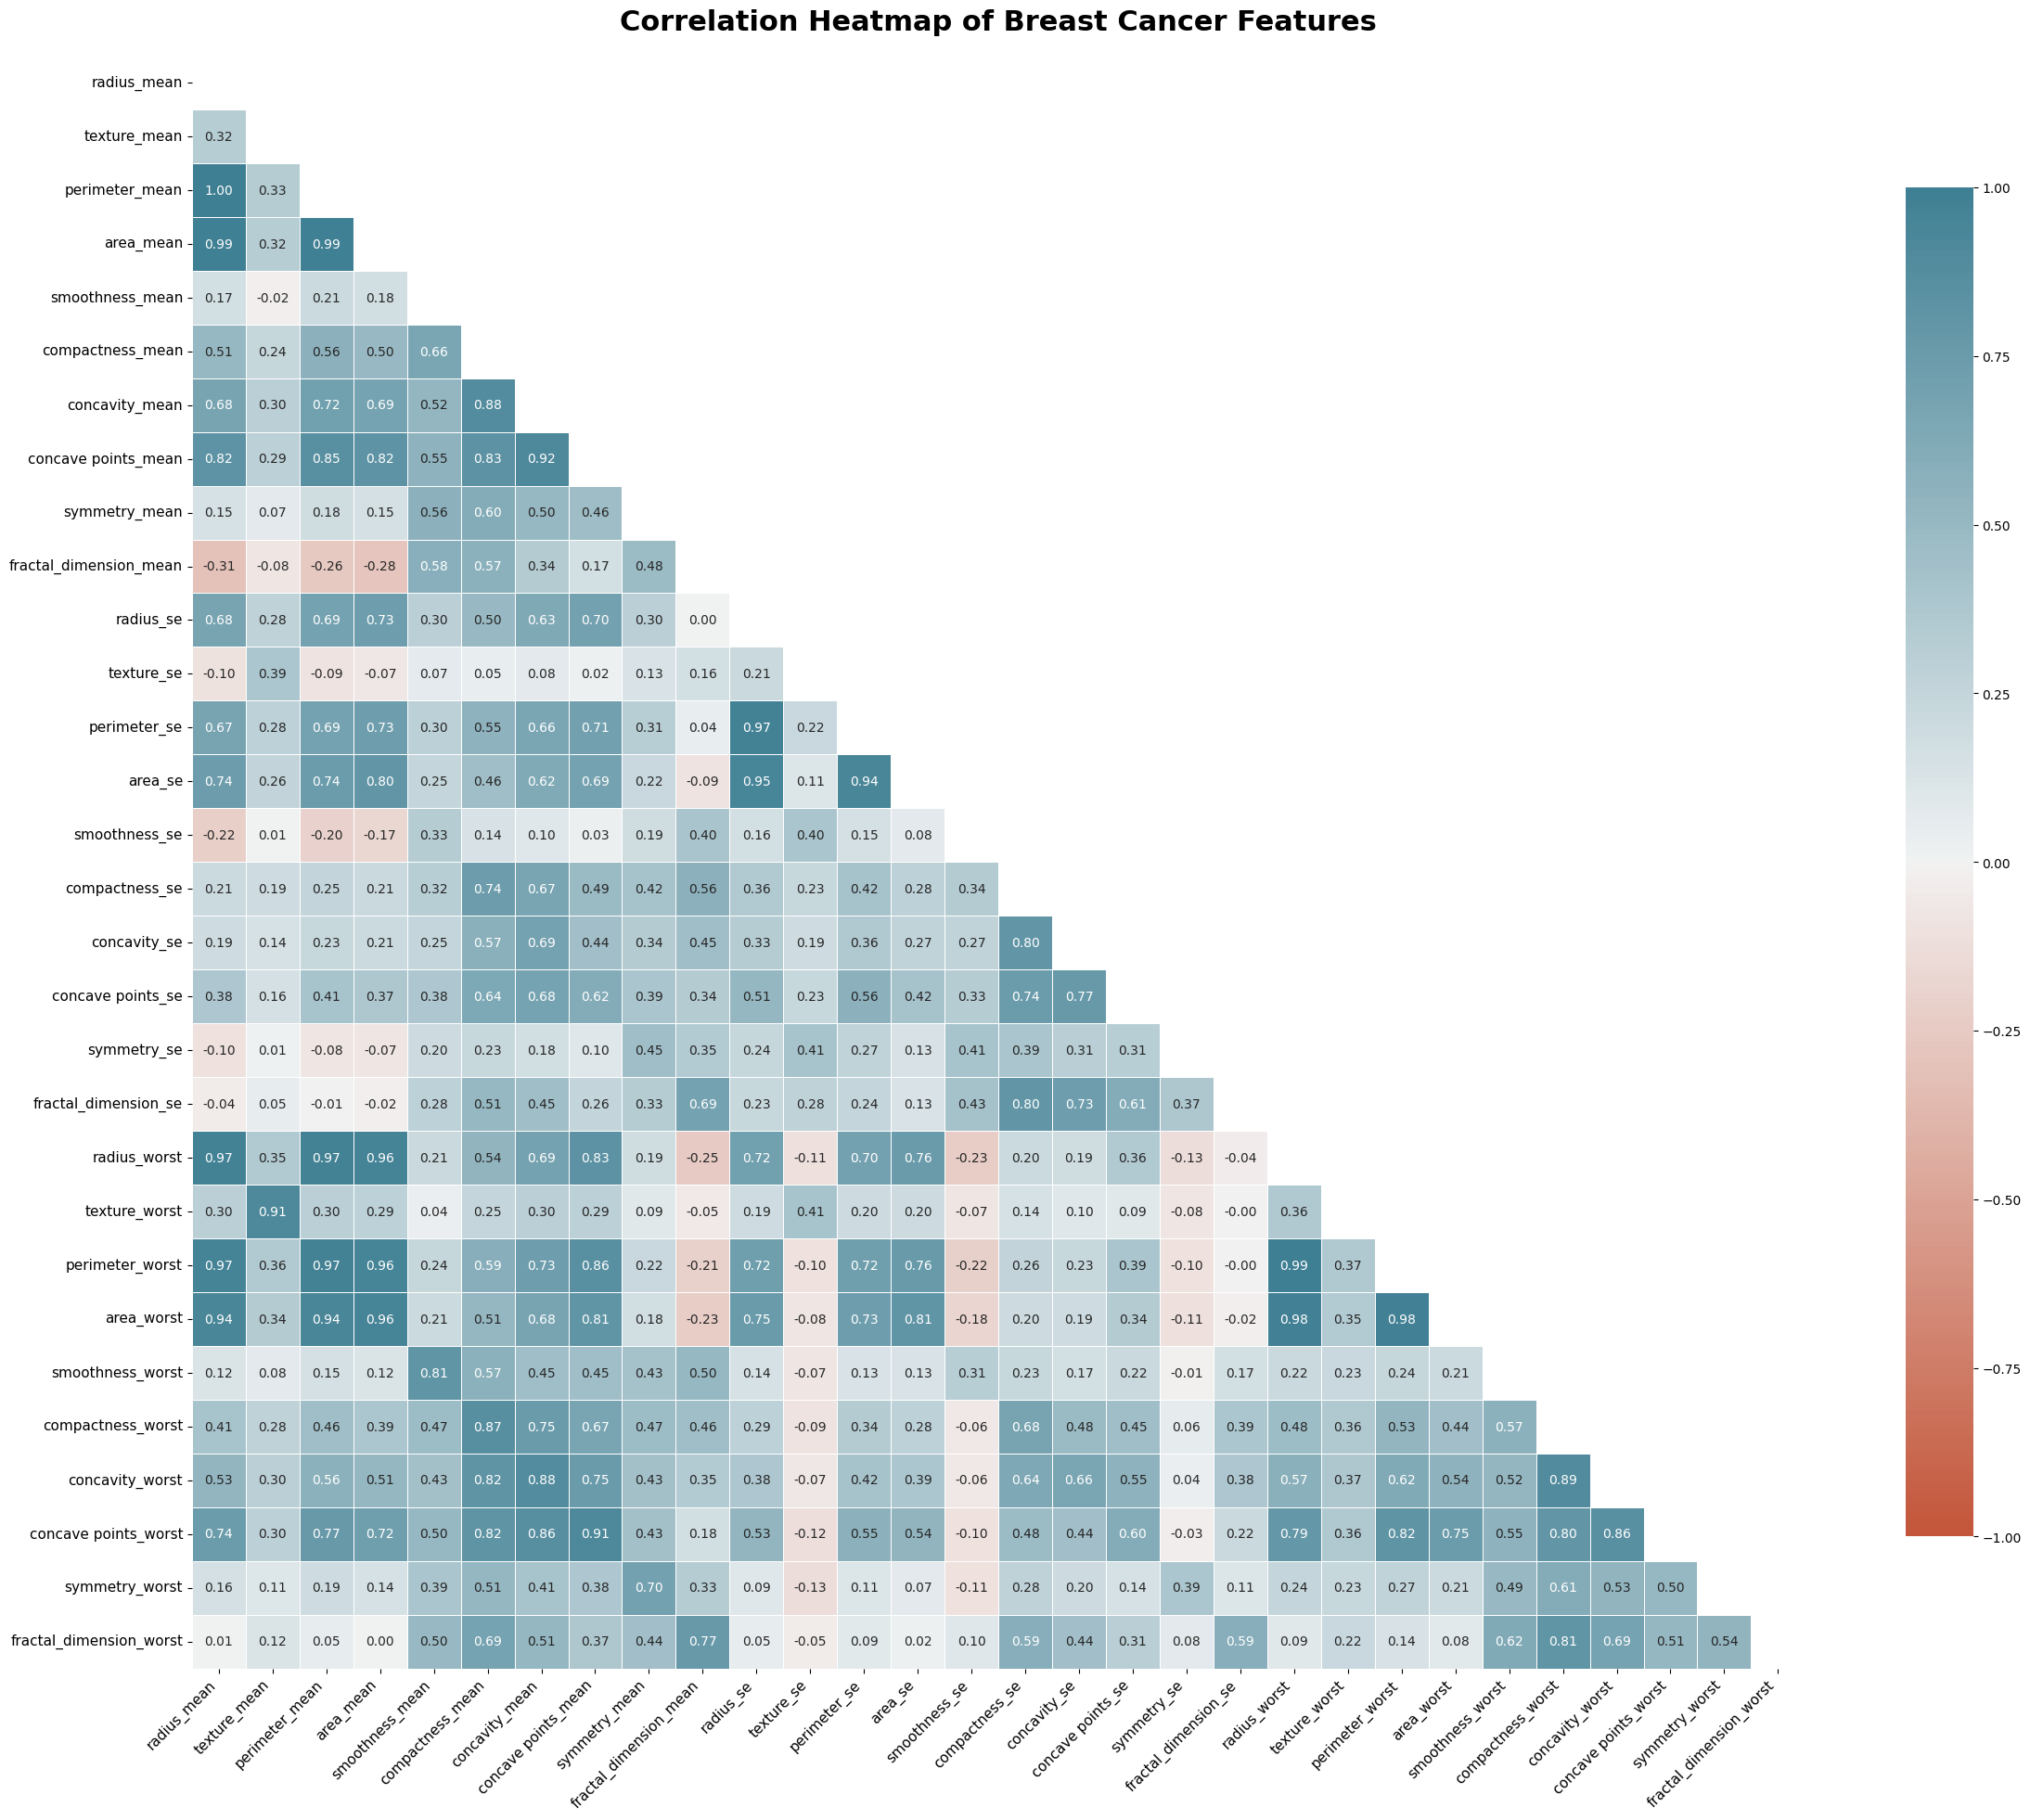

In [ ]:
# Step 1: Calculate correlation matrix (for numerical columns only)
corr_matrix = clean_data.corr(numeric_only = True)

# Step 2: Create a mask to hide the upper triangle (for a cleaner look)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Step 3: Set figure size (large enough for 30 columns)
plt.figure(figsize=(24, 20))

# Step 4: Set an attractive diverging color palette
custom_cmap = sns.diverging_palette(20, 220, as_cmap=True)

# Step 5: Plot the heatmap
sns.heatmap(corr_matrix,
            mask=mask,               # Hide upper part
            cmap=custom_cmap,        # Apply custom colors
            vmax=1.0, vmin=-1.0,     # Set scale from -1 to +1
            center=0,                # Set center to 0
            annot=True,              # Show numbers inside boxes
            fmt=".2f",               # Format to 2 decimal places
            square=True,             # Make cells perfectly square
            linewidths=0.5,          # Add lines between boxes
            cbar_kws={"shrink": .8}) # Resize color bar

# Step 6: Add titles and styling
plt.title("Correlation Heatmap of Breast Cancer Features", fontsize=22, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

# Show the plot
plt.tight_layout()
plt.show()

- The correlation heatmap reveals severe multicollinearity among several feature groups, identifiable by the dark teal squares where the correlation coefficient ($r$) exceeds 0.90. The most prominent highly correlated clusters are the size metrics: Radius, Perimeter, and Area. These metrics show near-perfect positive correlation (0.99 to 1.00) across all three categories (_mean, _se, and _worst). Additionally, shape descriptors such as Compactness, Concavity, and Concave Points also exhibit strong positive correlations (0.88 to 0.92). There are no significantly strong negative correlations (dark orange squares) that require immediate intervention.

#### Automated Feature Dropping :-

In [ ]:
# Step 1: Set threshold to 90% correlation
threshold = 0.90

# Step 2: Select upper half of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Step 3: Find columns with correlation > 0.90
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

# Step 4: Print the duplicate columns
print("Duplicate columns to drop:")
print(to_drop)
print(f"\nTotal dropped columns: {len(to_drop)}")

# Step 5: Drop columns to create the final dataset
data_dropped = clean_data.drop(columns=to_drop)
print(f"\nOld dataset size: {clean_data.shape}")
print(f"New dataset size: {data_dropped.shape}")

Duplicate columns to drop:
['perimeter_mean', 'area_mean', 'concave points_mean', 'perimeter_se', 'area_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'concave points_worst']

Total dropped columns: 10

Old dataset size: (569, 31)
New dataset size: (569, 21)


- The automated feature selection algorithm successfully identified and eliminated 10 highly correlated features, reducing the dataset's dimensionality from 31 to 21 columns (20 features + 1 target). The removed features primarily consisted of derived geometric measurements (Perimeter and Area across all categories) and redundant shape/texture metrics. By dropping these features, we have successfully resolved the issue of severe multicollinearity, ensuring that the upcoming kNN model will not be biased by duplicate information and will compute distances much more efficiently.

#### Target-Feature Relationship Analysis :-

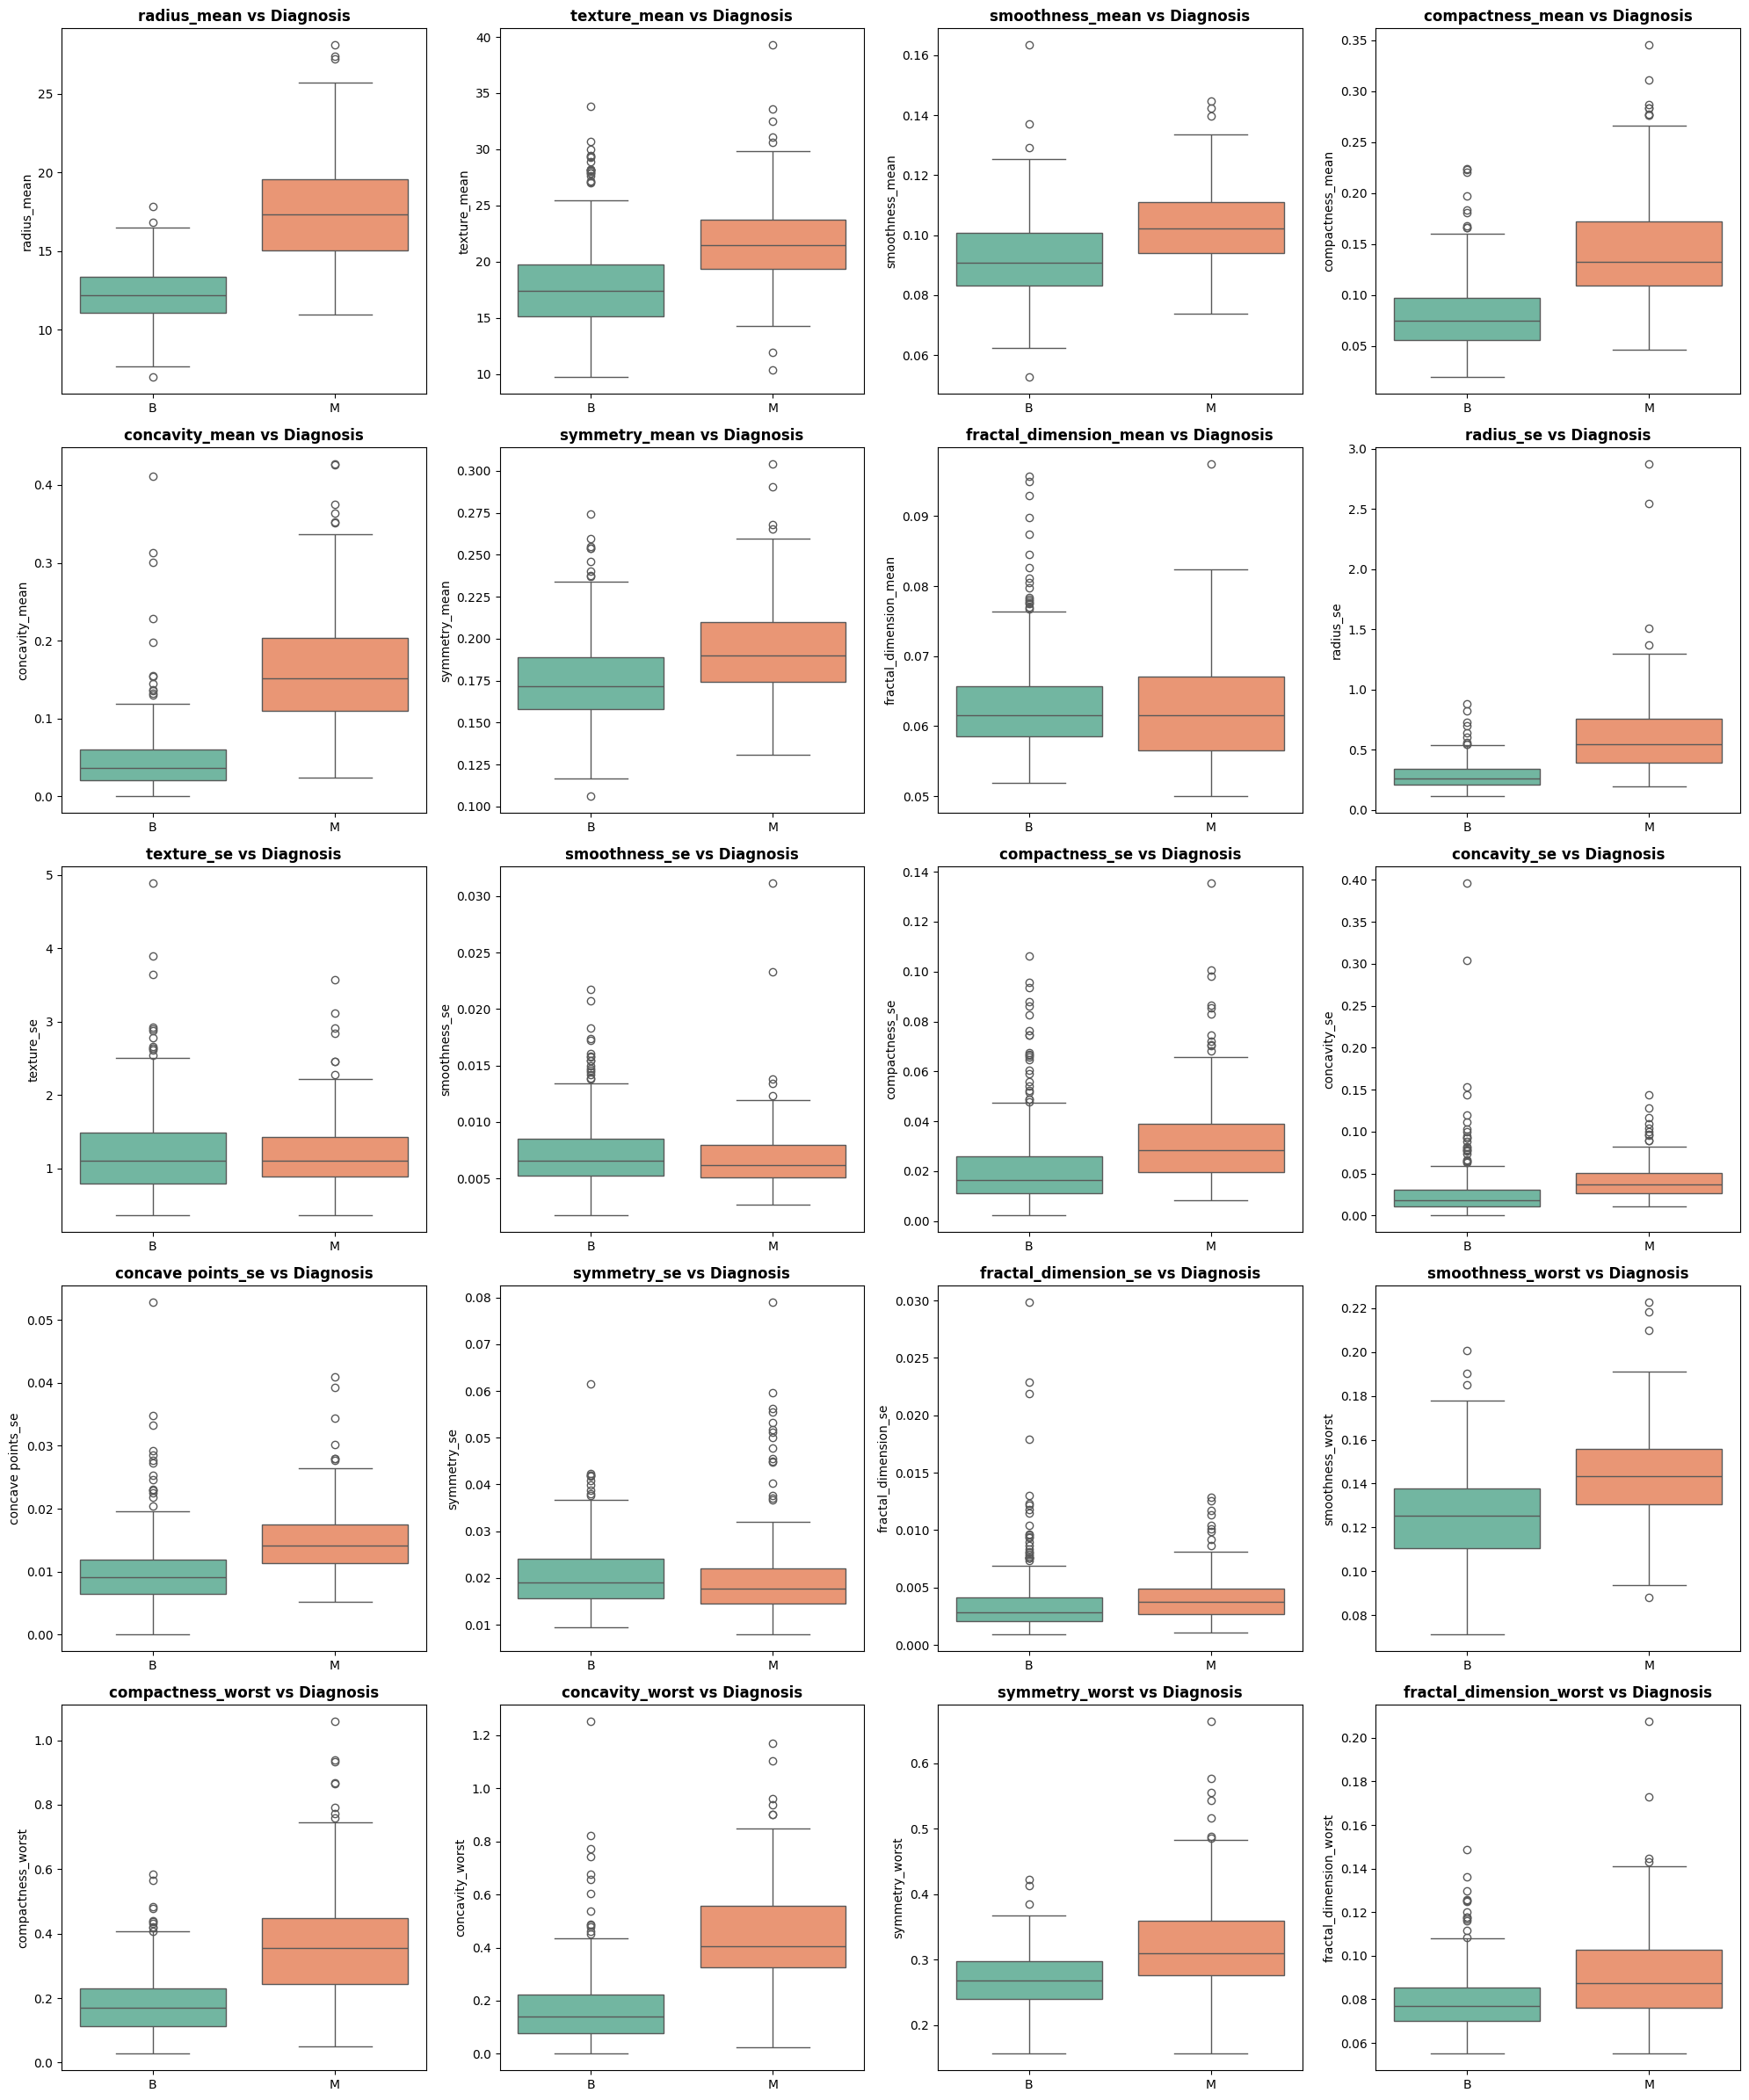

In [ ]:
# Step 1: Separated Target and features
target = 'diagnosis'
features = [col for col in data_dropped.columns if col != target]

# Step 2: Create 5x4 grid for 20 plots
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20, 24))
axes = axes.flatten()

# Step 3: Add loop for one by one all features
for i, col in enumerate(features):

    sns.boxplot(x=data_dropped[target], y=data_dropped[col], ax=axes[i],
                hue=data_dropped[target], palette="Set2", legend=False)

    # Add title and labels
    axes[i].set_title(f"{col} vs Diagnosis", fontsize=12, fontweight='bold')
    axes[i].set_xlabel("")
    axes[i].set_ylabel(col)

# Step 4: Adjust layout because plot don't overlaped
plt.tight_layout()
plt.show()

##### **The grid of 20 bivariate boxplots illustrates the varying discriminatory power of the remaining features against the target variable (diagnosis).**

- **Strong Predictors:** Several shape and size metrics (e.g., radius_mean, concavity_mean, compactness_worst) exhibit clear vertical separation between the interquartile ranges of Benign (B) and Malignant (M) classes, with Malignant tumors consistently showing higher values and wider variance.

- **Weak Predictors:** Conversely, certain standard error metrics and fractal dimensions (e.g., fractal_dimension_mean, texture_se, smoothness_se) display almost complete overlap between their respective boxes, indicating that these features possess little to no predictive power for distinguishing between tumor types.

## Data Preprocessing..

#### Encoding and Splitting :-

In [ ]:
# Target Encoding ("M" -> 1, "B" -> 0)
data_dropped["diagnosis"] = data_dropped["diagnosis"].map({"M":1, "B":0})
print("Encoding Complete")

Encoding Complete


- Machine Learning models only understand math, not English alphabets. This step has converted all 'Malignant' tumors to 1 and 'Benign' to 0. Now your target column has become strictly numerical.

In [ ]:
# Splitting data into Independent Features (X) and Dependent Target (y)
X = data_dropped.drop(columns = ["diagnosis"])
y = data_dropped["diagnosis"]

print(f"Total Data (X) Shape: {X.shape}")

Total Data (X) Shape: (569, 20)


- **Separation of X and Y:** we put all the 20 features into the X variable, and the one to be predicted (Diagnosis) is taken out into the Y variable alone.

In [ ]:
# Train-Test Split (80% Traning, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size =0.20, random_state = 10, stratify = y)

print(f"Traning Data (X_train) Shape: {X_train.shape}")
print(f"Testing Data (X_test) Shape: {X_test.shape}")

Traning Data (X_train) Shape: (455, 20)
Testing Data (X_test) Shape: (114, 20)


- **test_size=0.20:** This sets aside 20% (approximately 114 patients) of the 569 patients in the entire dataset for the test set, and the model will train on the remaining 80% (455 patients).

- **stratify=y:** This is an advanced parameter. It ensures that the ratio of Cancer (1) and Normal (0) patients is maintained exactly equal in both the Train and Test datasets, so that the model's learning is balanced.

#### Feature Scalling :-

In [ ]:
# Initialize the Standard Scaler
scaler = StandardScaler()

# Fit and transform the traning data only
X_train_scaled = scaler.fit_transform(X_train)

# Transform the testing data (No fitting here to prevent data leakage)
X_test_scaled = scaler.transform(X_test)

print("Feature Scalling Complete!\n")
print("First row of scaled traning data:")
print(X_train_scaled[0])

Feature Scalling Complete!

First row of scaled traning data:
[-0.02417551 -1.48121936 -0.24835796 -0.97779951 -0.90019713 -1.60888527
 -0.79060494 -0.52656006 -0.22836416 -0.1015202  -0.79804305 -0.91076131
 -0.86783108 -0.74675925 -0.49079406 -0.20435324 -0.91498107 -1.07972542
 -1.31165457 -0.71145132]


- **scaler = StandardScaler():** We told the machine to create an empty scale that would fit the data with Mean = 0 and Standard Deviation = 1.

- **scaler.fit_transform(X_train):** This is the most important line. It does two things simultaneously:

- **fit:** Scaler simply calculated the average (Mean) and SD of the columns of X_train and stored them in memory.

- **transform:** Based on this calculated average, all the large and small values ​​of X_train (such as area and smoothness) were transformed to a uniform scale of -3 to +3, eliminating the large differences.

- **scaler.transform(X_test):** We did not use the word fit here. This means the scaler didn't calculate a new average for the test data, but instead silently scaled the test data using the same rules it learned from the training data. No cheating, no data leakage!

## kNN Model Initialization & Traning..

In [ ]:
# Initialize model (set k = 5)
knn = KNeighborsClassifier(n_neighbors = 5)

# Train model
knn.fit(X_train_scaled, y_train)

print("kNN Model Successfully Trained!")
print("Now your model is ready for prediction")

kNN Model Successfully Trained!
Now your model is ready for prediction


- **KNeighborsClassifier(n_neighbors=5):** Here we generated our kNN model.
n_neighbors=5 means that whenever a new (test) patient comes, the model will find his/her 5 closest neighbors (neighbors) in the graph. If 3 out of those 5 are log Malignant (1), then the model will declare the new patient as Malignant as well (Majority Voting).

- **knn.fit(X_train_scaled, y_train):** This is the "training" step of your model. It memorizes all the data points (your 20 features) of X_train_scaled and all the answers (0 or 1) of y_train by plotting them on a graph.

## Model Evaluation

In [ ]:
# Ready for prediction
y_pred = knn.predict(X_test_scaled)

#### Accuracy Score :-

In [ ]:
#Calculate Accuracy Score
accuracy = accuracy_score(y_test, y_pred)

print(f"kNN Model Accuracy: {accuracy * 100:.2f}%\n")

kNN Model Accuracy: 95.61%



#### Confusion Matirx :-

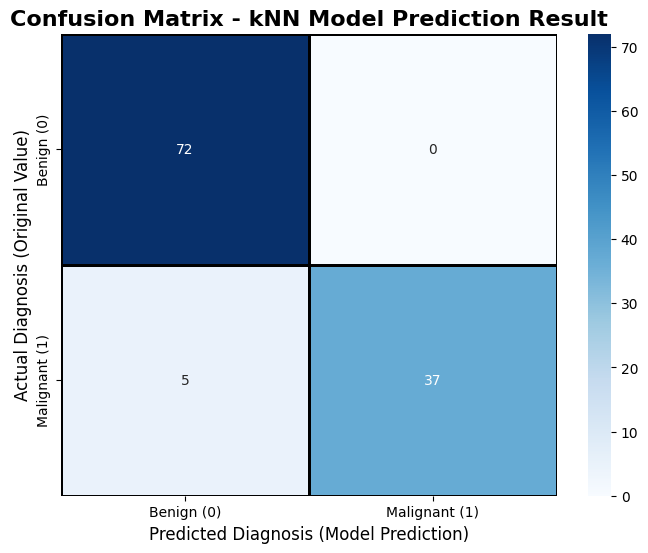

In [ ]:
# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Create a Heatmap for Confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels = ["Benign (0)", "Malignant (1)"],
            yticklabels = ["Benign (0)", "Malignant (1)"],
            linewidths = 1, linecolor = "black")
plt.title("Confusion Matrix - kNN Model Prediction Result", fontsize = 16, fontweight = "bold")
plt.xlabel("Predicted Diagnosis (Model Prediction)", fontsize = 12)
plt.ylabel("Actual Diagnosis (Original Value)", fontsize = 12)
plt.show()

##### **1. The Success Metrics (Correct Decisions)**
- **True Negatives (72):** Your model correctly identified 72 patients as not having cancer (Benign).

- **True Positives (37):** The model perfectly detected 37 patients who actually had cancer (Malignant). These are life-saving predictions!

- **False Positives (0):** This is an absolute zero! This means your model did not scare any healthy patients by mistakenly identifying them as having cancer. Such a zero is seen in very few models.

##### **2. The Danger Zone (Mistakes)**
- **False Negatives (5):** This is where your model missed a bit. There were 5 patients who had cancer (Malignant), but the model considered them benign (Normal). In Medical ML, our main goal is to reduce this number.

- **Top-Left Box (True Negatives):** These are patients who did not actually have cancer, and your model correctly identified them.

- **Bottom-Right Box (True Positives):** These are critical patients who did have cancer, and the model correctly identified them.

- **Top-Right Box (False Positives):** The model mistakenly diagnosed a normal patient with cancer (here the patient may be a little nervous, but there is no life-threatening danger).

- **Bottom-Left Box (False Negatives) DANGER ZONE:** This number should be the smallest or zero in your graph! This means the patient did have cancer, but the model said "you're right." This mistake can prove very costly in real life.

#### Detailed Report :-

In [ ]:
print("\nDetailed Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Benign (0)", "Malignant (1)"]))


Detailed Classification Report:

               precision    recall  f1-score   support

   Benign (0)       0.94      1.00      0.97        72
Malignant (1)       1.00      0.88      0.94        42

     accuracy                           0.96       114
    macro avg       0.97      0.94      0.95       114
 weighted avg       0.96      0.96      0.96       114



1. **Overall Accuracy:** > The kNN model achieved an impressive overall accuracy of 96%. Out of the 114 test patients, the model made the correct prediction 96% of the time.

2. **Performance on Benign (Healthy) Cases:**

- **Recall is 1.00 (100%):** This means the model successfully identified all 72 actual healthy patients. It did not miss a single healthy person.

3. **Performance on Malignant (Cancer) Cases:**

- **Precision is 1.00 (100%):** This means whenever the model declared a patient as "Malignant", it was absolutely correct every single time. There were zero false alarms.

- **Recall is 0.88 (88%):** This is the only weak point. It means out of all the actual cancer patients, the model only caught 88% of them. It missed 12% of the cancer cases (the 5 False Negatives we saw in the confusion matrix).

## Real-Time Prediction Check..

In [ ]:
# Dictionary to map numerical outputs to readable text
diagnosis_map = {0: "Benign (Safe - No Cancer)", 1: "Malignant (Danger - Cancer)"}

# Step 1: Ask user for input (Test data has 114 patients, so valid index is 0 to 113)
row_number = int(input("Enter a patient row number from Test Data (0 to 113): "))

# Step 2: Fetch the patient's scaled features and actual diagnosis
# Reshape is required because the model expects a 2D array (1 row, 20 columns)
test_patient_data = X_test_scaled[row_number].reshape(1, -1)
original_value = y_test.iloc[row_number]

# Step 3: kNN model makes the prediction based on the given features
predicted_value = knn.predict(test_patient_data)[0]

# Step 4: Convert numerical results (0 or 1) to human-readable text
original_text = diagnosis_map[original_value]
predicted_text = diagnosis_map[predicted_value]

# Step 5: Compare the model's prediction with the actual diagnosis
if original_value == predicted_value:
  status = "PERFECT MATCH!"
else:
  status = "MISMATCH!"

# Step 6: Print the final interactive test report
print("\n" + "="*55)
print(f"BREAST CANCER PREDICTION CHECK (Patient Index: {row_number})")
print("="*55)
print(f"Doctor's Actual Report :  {original_text}")
print(f"kNN Model's Prediction :  {predicted_text}")
print("-" * 55)
print(f"Result                 :  {status}")
print("="*55)

Enter a patient row number from Test Data (0 to 113): 12

BREAST CANCER PREDICTION CHECK (Patient Index: 12)
Doctor's Actual Report :  Benign (Safe - No Cancer)
kNN Model's Prediction :  Benign (Safe - No Cancer)
-------------------------------------------------------
Result                 :  PERFECT MATCH!


### Why We Did Not Remove Outliers
During our Exploratory Data Analysis (EDA), we observed several outliers across the feature set. However, we intentionally chose not to remove them for the following reasons:

1. **Medical Domain Context:** In the context of Breast Cancer detection, extreme values (outliers) in cell nuclei measurements—such as unusually large areas or highly irregular shapes—are natural biological indicators of Malignant tumors. They are not data entry errors or noise.

2. **Prevention of Information Loss:** Removing these outliers would mean deleting data belonging to patients with severe tumor conditions. This would lead to a biased model that fails to detect critical, extreme cancer cases in the real world (increasing False Negatives).

3. **Handled via Feature Scaling:** Instead of dropping these critical data points, we applied StandardScaler. This technique standardizes the range of all features (Mean = 0, SD = 1), ensuring that extreme numerical values do not mathematically dominate or skew the kNN algorithm's Euclidean distance calculations, while still preserving their biological significance.